# RNA Substrates of Memory and Forgetting in Stentor coeruleus 

## Notebook Setup

In [1]:
#Notebook Setup

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS
from statsmodels.stats.multitest import fdrcorrection
from matplotlib import rc
from scipy import stats
from scipy.stats import zscore

import os
import pickle as pkl

rc('text', usetex=False)
rc('text.latex', preamble=r'\usepackage{cmbright}')
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

%matplotlib inline

# This enables SVG graphics inline. 
%config InlineBackend.figure_formats = {'png', 'retina'}

rc = {'lines.linewidth': 2,
      'axes.labelsize': 18, 
      'axes.titlesize': 18, 
      'axes.facecolor': 'DFDFE5'}
sns.set_context('notebook', rc=rc)
sns.set_style("dark")

mpl.rcParams['xtick.labelsize'] = 16 
mpl.rcParams['ytick.labelsize'] = 16 
mpl.rcParams['legend.fontsize'] = 14

## Load data (with time 0)

In [2]:
# read sleuth matrix 
df = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/exp2_rna_sleuth_obsnorm.csv').rename(columns={'Unnamed: 0': 'gene'}).set_index('gene')

In [3]:
# read sleuth stat results 
stat_df = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/exp2_rna_sleuth_lrt.csv').set_index('target_id')

In [4]:
# samples to conditions (s2c)
s2c = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/bin/conditions.csv', index_col = 'sample')

### Color setup

In [5]:
# load color dictionary 

filename = "learnsample_color_dict.pkl"

with open(filename, "rb") as file:
    color_dict = pkl.load(file)

In [6]:
color_dict

{'t_0': '#4477AA',
 'ut_19': '#EE6677',
 't_19': '#228833',
 'f_10': '#CCBB44',
 'ut_f_10': '#66CCEE',
 'f_90': '#AA3377',
 'ut_f_90': '#BBBBBB'}

In [7]:
# label dictionary for legends in figures 

label_dict = {
    't_0':'time 0',
    'ut_19':'19 hrs no training', 
    't_19':'19 hrs training',
    'f_10':'19 hrs training + 10 min forgetting',
    'f_90': '19 hrs training + 90 min forgetting', 
    'ut_f_10':'19 hrs + 10 min no training', 
    'ut_f_90':'19 hrs + 90 min no training'
}


### Filter s2c and color_dict

Note: we decided to remove ut_f_10 and ut_f_90 because there is no statistically significant difference between these controls and ut_19. 

In [8]:
samples_to_remove = s2c.index[s2c["condition"].isin(['ut_f_10', 'ut_f_90'])]

s2c = s2c.drop(index=samples_to_remove)

In [9]:
# Filter color dict for samples kept 
color_dict = {key: value for key, value in color_dict.items() if key in s2c['condition'].unique()}

In [10]:
color_dict

{'t_0': '#4477AA',
 'ut_19': '#EE6677',
 't_19': '#228833',
 'f_10': '#CCBB44',
 'f_90': '#AA3377'}

## Data Prep and PCA

                  PC1         PC2
DR4876_01  -82.986147   59.050451
DR4876_02  106.078440  129.294102
DR4876_03  -73.684617   36.189266
DR4876_04  -66.050382   15.273311
DR4876_05  176.163984   20.706228


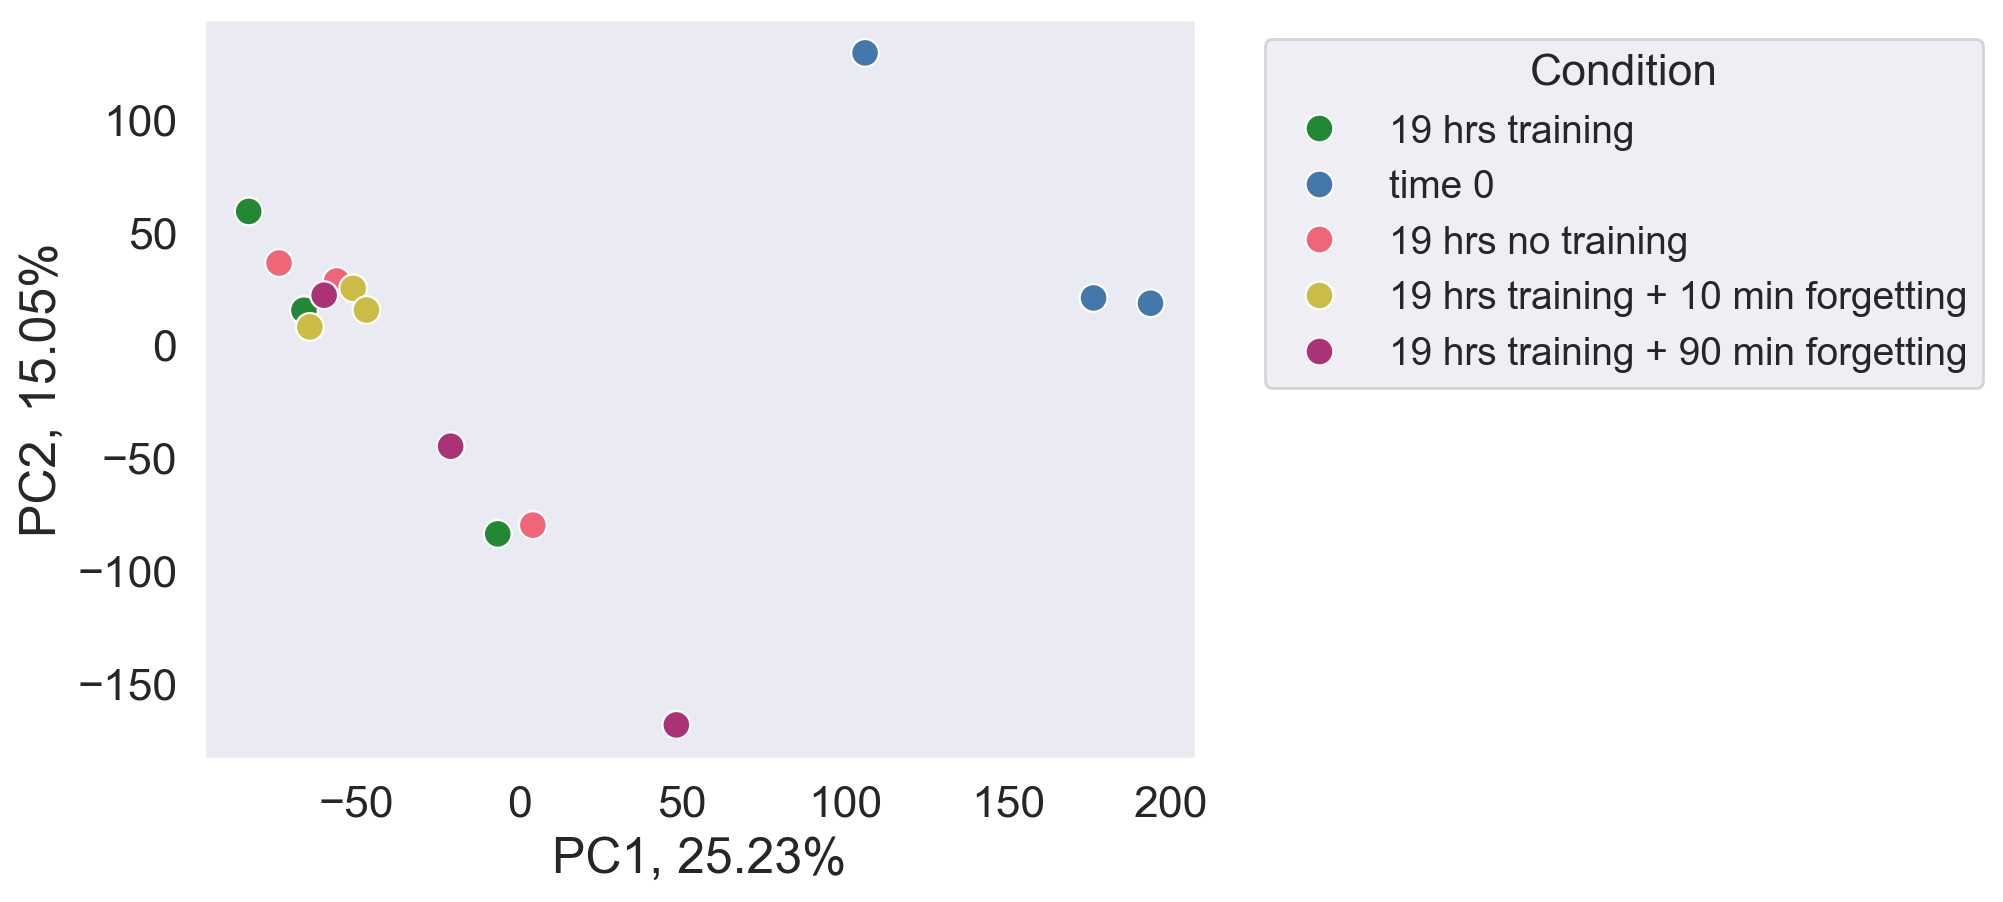

In [11]:
# Standardize the data: mean = 0, std = 1
scaler = SS()
scaled_data = scaler.fit_transform(df.T)

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
coords = pca.fit_transform(scaled_data)

# Create DataFrame with PCA results
pc = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df.T.index)

# Print to check PCA results
print(pc.head())

pc = pd.merge(pc, s2c, left_index=True, right_index=True)

explained_variance = pca.explained_variance_ratio_ * 100  # convert to percentage
# Add variance explained to axis labels
plt.xlabel(f'PC1, {explained_variance[0]:.2f}%')
plt.ylabel(f'PC2, {explained_variance[1]:.2f}%')

# Plot PCA results
sns.scatterplot(x='PC1', y='PC2', hue='condition', palette=color_dict,
                s=100, data=pc)

# current legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# replace shorthand labels
new_labels = [label_dict[label] for label in labels]

# update legend 
plt.legend(handles, new_labels, title="Condition", title_fontsize = 16, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Note: PC1 appears to separate t_0 samples from the rest of the data. Safe to assume the largest amount of variation is a result of time. 

# Heatmap

In [12]:
sig_df = stat_df[stat_df.qval <= 0.05]

Note: there are clear differences because of time 0 and a ton of statistically significant genes as a result... using a lower threshold here there are nearly 4k statistically significantly different genes. Only the top 50 most statistically significant will be plotted in the heatmap 

In [13]:
top_50_genes = sig_df.sort_values('qval').head(50)

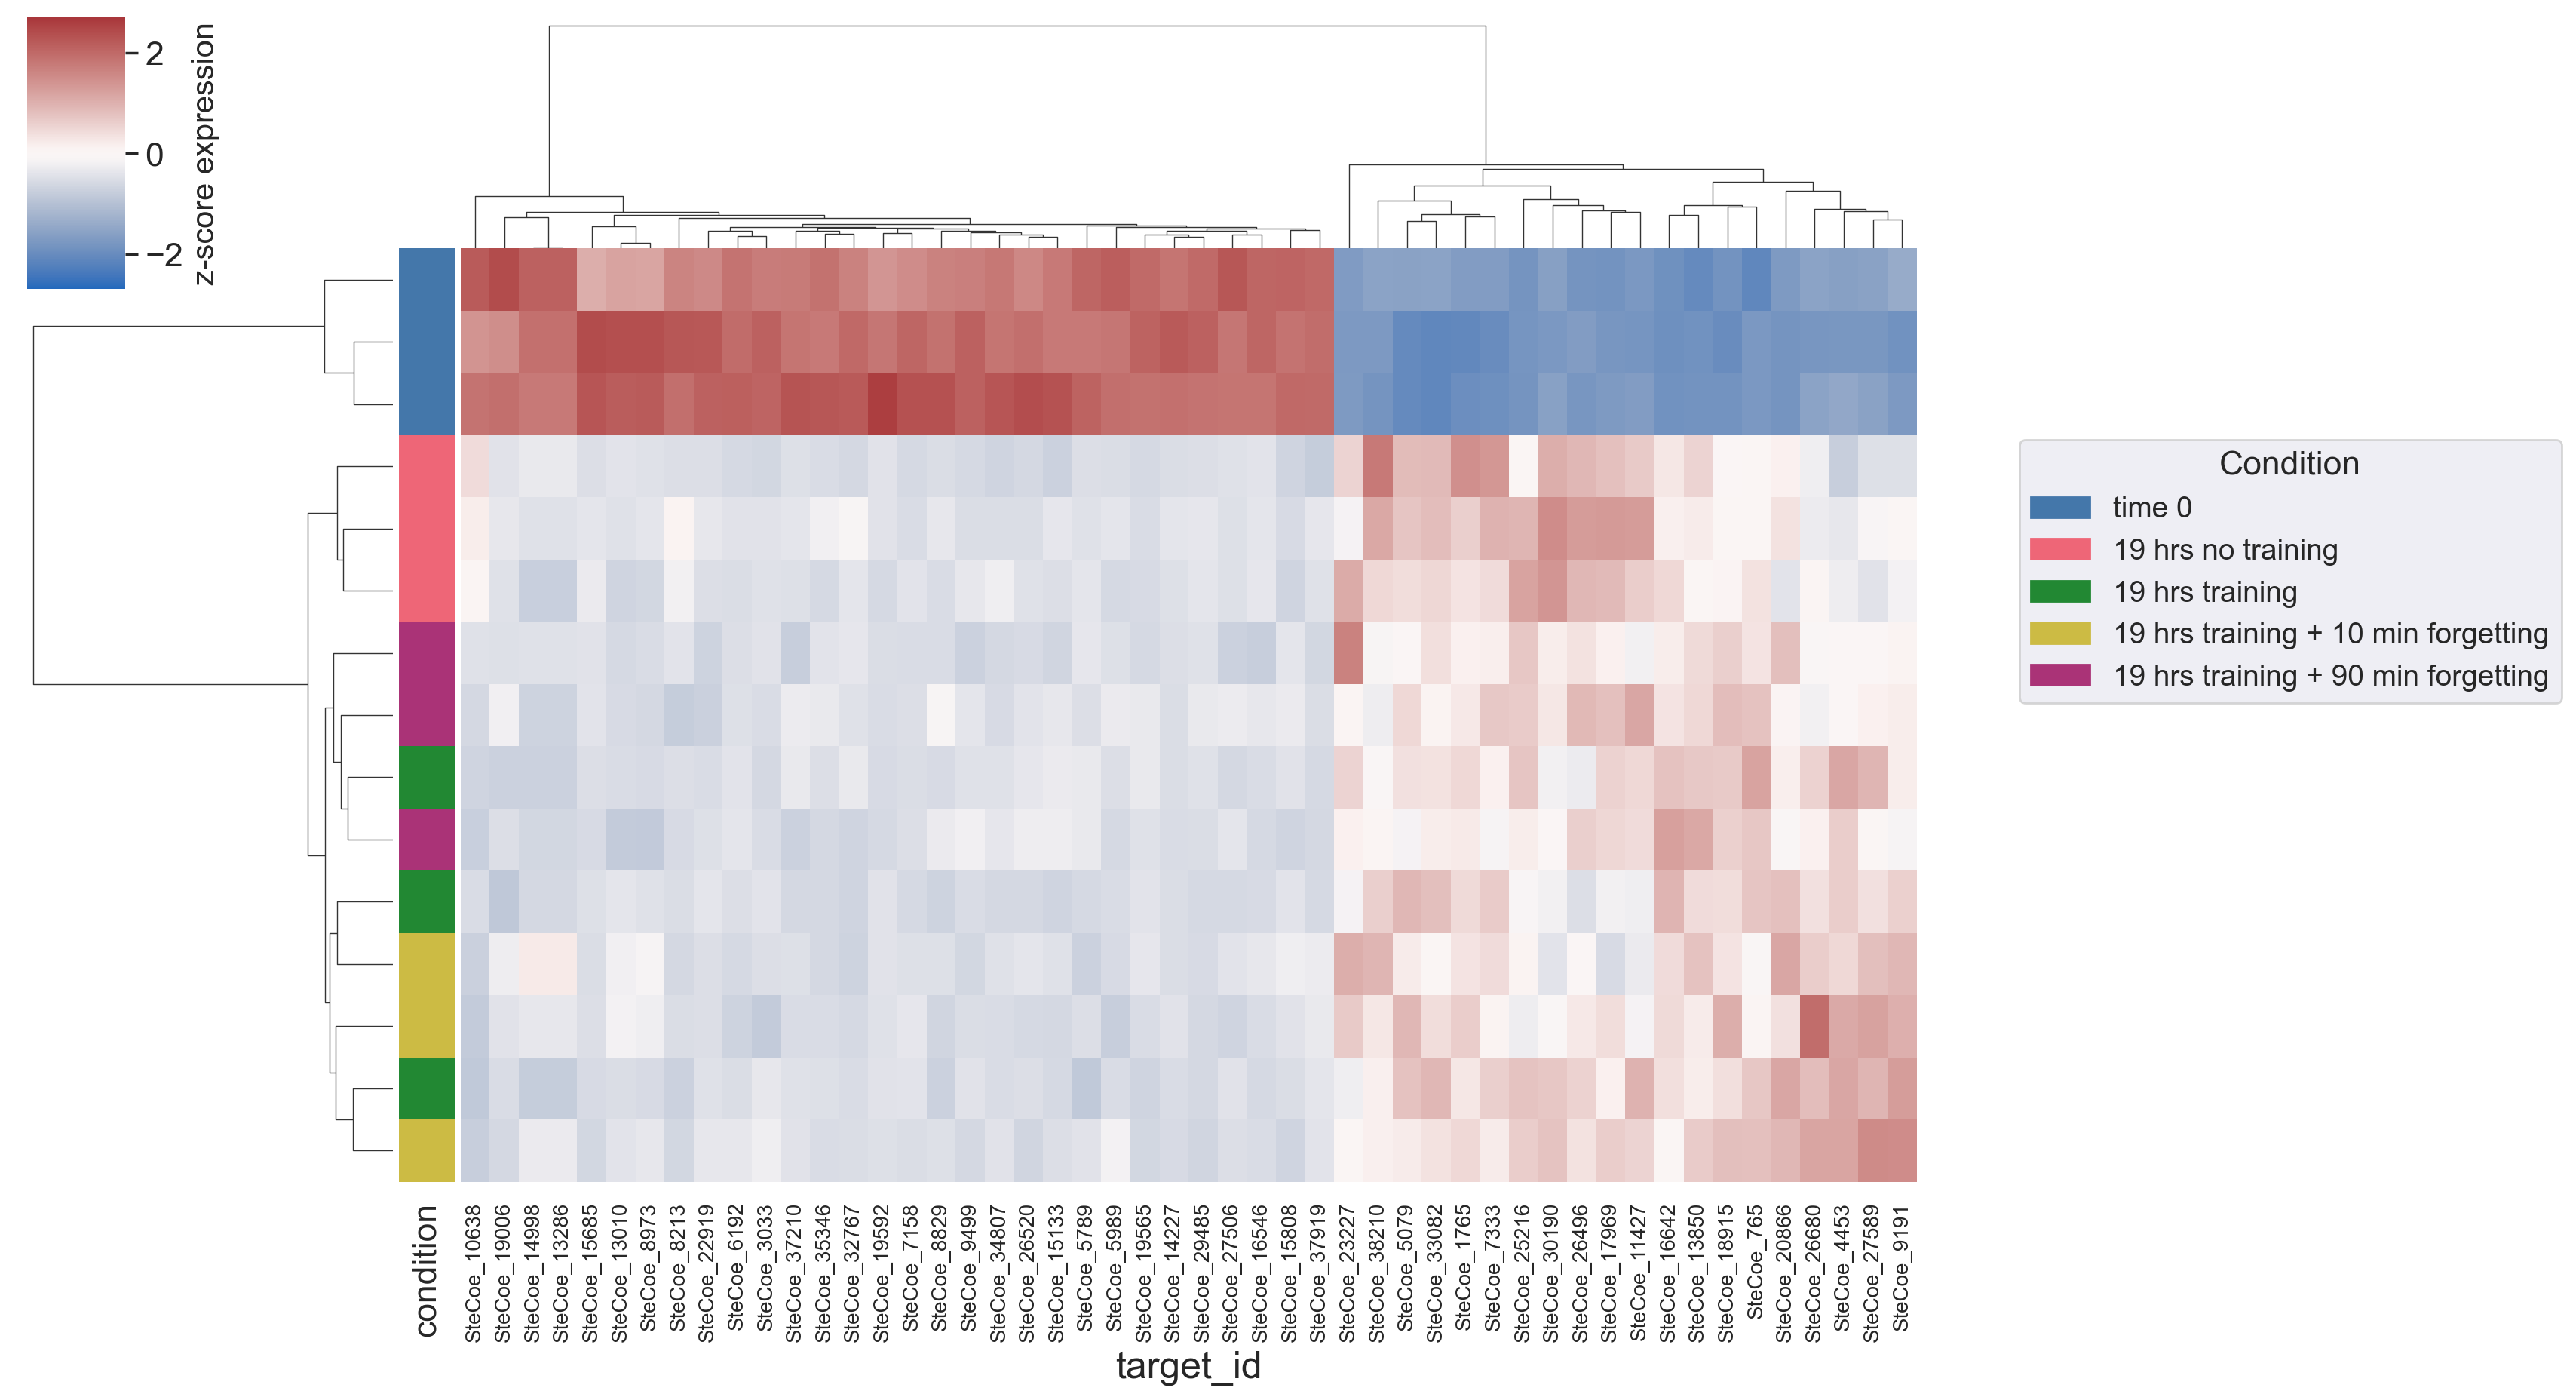

In [14]:
##### heatmap of top statistically significant

# get expression data 
top_50_gene_names = top_50_genes.index
top_50_expr = df.loc[top_50_gene_names]

# z-score normalize
top_50_expr_zscore = top_50_expr.apply(zscore, axis=1)

# map sample to color
row_colors = s2c['condition'].map(color_dict)

# plot
g = sns.clustermap(
    top_50_expr_zscore.T,  # samples as rows
    cmap="vlag",  # z-score colormap
    annot=False,  # don't need annot
    figsize=(13, 10),  # plot size
    row_colors=row_colors,  # color rows based on condition
    xticklabels = True, # show all sample IDs, 
    yticklabels = False, 
    vmin = -2.7, # set min max, center around 0 
    vmax = 2.7, 
    cbar_kws={'label': 'z-score expression'}
)

g.figure.axes[-1].yaxis.label.set_size(15)

# condition legend and position relative to z-score colorbar
handles = [mpatches.Patch(color=color_dict[key], label=label_dict[key]) for key in color_dict]
plt.legend(handles=handles, title="Condition", bbox_to_anchor=(26, -0.5), loc='upper right', fontsize = 14, title_fontsize = 16)

# gene font angle and size 
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=10)  

# save
plt.savefig("exp2_rna_hm_obsnorm_zscore_with0.png", dpi=300, bbox_inches='tight')

# show
plt.show()


## Without t_0 

Given the fact that Time 0, which represents when the cells were first put into a dish, dominates... we decided to remove those samples. 

In [15]:
# read sleuth matrix 
df_no0 = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/exp2_rna_no0_sleuth_obsnorm.csv').rename(columns={'Unnamed: 0': 'gene'}).set_index('gene')

In [16]:
# read sleuth stat results 
stat_df_no0 = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/exp2_rna_no0_sleuth_lrt.csv').set_index('target_id')

In [17]:
samples_to_remove = s2c.index[s2c["condition"].isin(["t_0", "ut_f_10", "ut_f_90"])]
df_no0 = df.drop(columns=samples_to_remove)
s2c_no0 = s2c.drop(index=samples_to_remove)

In [18]:
# Filter color dict for samples kept 
color_dict_no0 = {key: value for key, value in color_dict.items() if key in s2c_no0['condition'].unique()}

In [19]:
color_dict_no0

{'ut_19': '#EE6677', 't_19': '#228833', 'f_10': '#CCBB44', 'f_90': '#AA3377'}

In [20]:
label_dict_no0 = {
    't_19': '19 hrs training',
    'ut_19': '19 hrs no training',
    'f_10': '19 hrs training + 10 min forgetting',
    'f_90': '19 hrs training + 90 min forgetting'
}

In [21]:
s2c_no0

,condition,batch,paradigm
sample,,,
DR4876_01,t_19,1,Trained for 19 hrs
DR4876_03,ut_19,1,No training for 19 hrs
DR4876_04,t_19,2,Trained for 19 hrs
DR4876_06,ut_19,2,No training for 19 hrs
DR4876_07,t_19,3,Trained for 19 hrs
DR4876_09,ut_19,3,No training for 19 hrs
DR4876_10,f_10,4,Trained for 19 hrs + 10 min forgetting
DR4876_12,f_10,5,Trained for 19 hrs + 10 min forgetting
DR4876_14,f_10,6,Trained for 19 hrs + 10 min forgetting


                 PC1         PC2
DR4876_01  97.470504   69.343003
DR4876_03  72.250737  126.288246
DR4876_04  46.969167  -40.917646
DR4876_06  51.578061  -17.090829
DR4876_07 -86.756463    6.140403


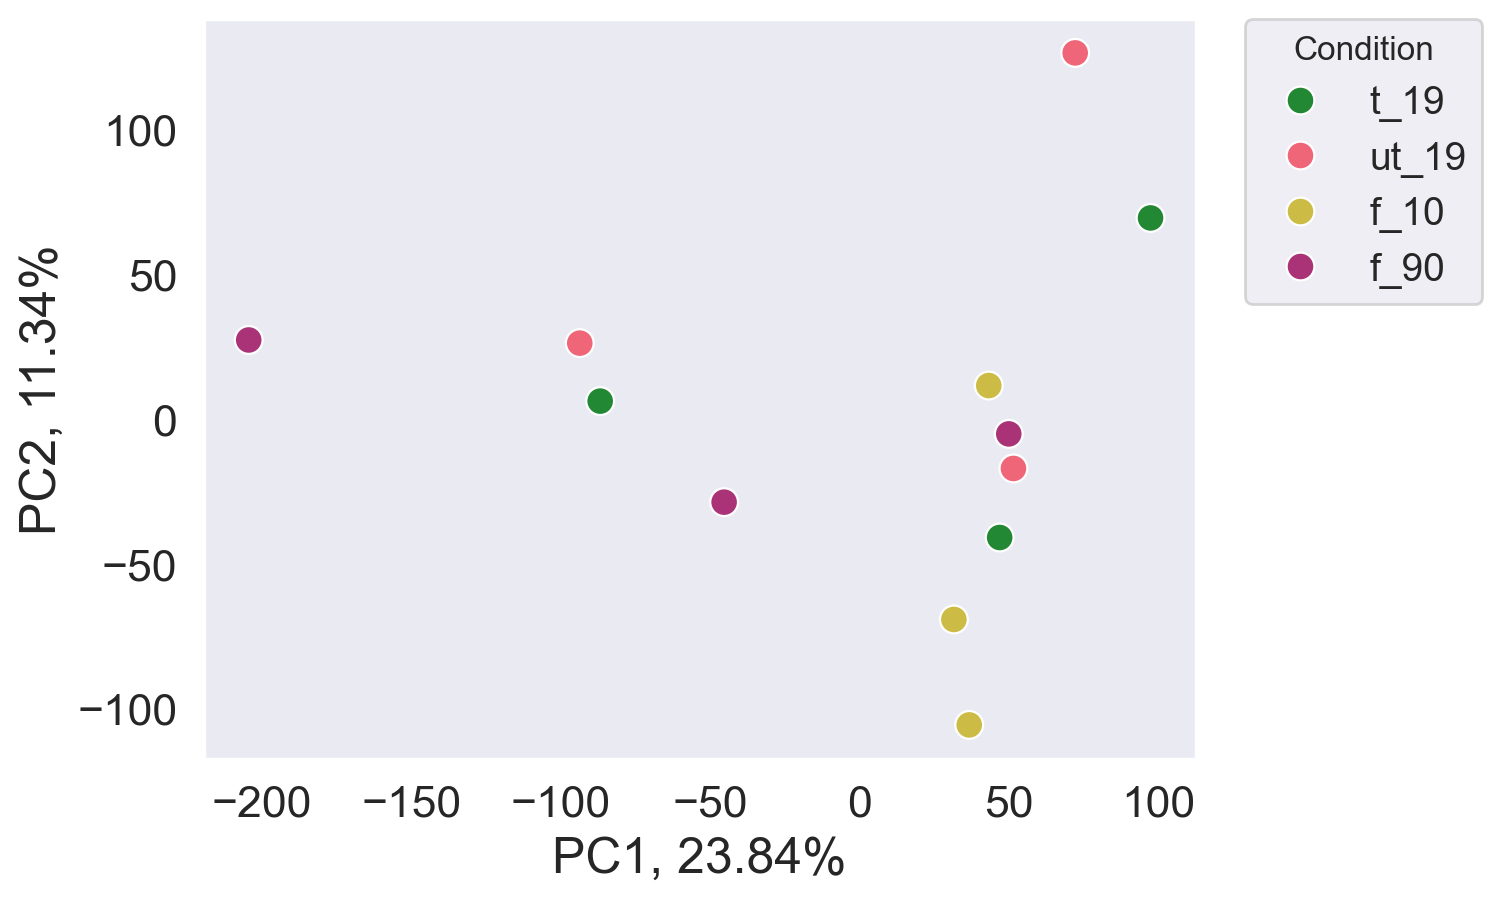

In [22]:
# Standardize the data: mean = 0, std = 1
scaler = SS()
scaled_data = scaler.fit_transform(df_no0.T)

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
coords = pca.fit_transform(scaled_data)

# Create DataFrame with PCA results
pc = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df_no0.T.index)

# Print to check PCA results
print(pc.head())

pc = pd.merge(pc, s2c_no0, left_index=True, right_index=True)

explained_variance = pca.explained_variance_ratio_ * 100  # convert to percentage
# Add variance explained to axis labels
plt.xlabel(f'PC1, {explained_variance[0]:.2f}%')
plt.ylabel(f'PC2, {explained_variance[1]:.2f}%')

# Plot PCA results
sns.scatterplot(x='PC1', y='PC2', hue='condition', palette = color_dict_no0,
                s=100, data=pc)

# Customize legend
plt.legend(title = "Condition", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Customize ticks (optional)
# plt.xticks([-50, 0, 50, 100])
# plt.yticks([-50, 0, 50, 100])

# Save the plot
#plt.savefig('20250331/RNA_PCA_conditions_no0.png', bbox_inches='tight', dpi=300)

plt.show()

In [23]:
sig_df_no0 = stat_df_no0[stat_df_no0.qval <= 0.3]

In [24]:
top_50_genes_no0 = sig_df_no0.sort_values('qval').head(50)

In [25]:
top_50_genes_no0

,Unnamed: 0,pval,qval,test_stat,rss,degrees_free,mean_obs,var_obs,tech_var,sigma_sq,smooth_sigma_sq,final_sigma_sq
target_id,,,,,,,,,,,,
SteCoe_10638,1,0.000011,0.152824,25.667060,1.756714,3.0,4.784889,0.159701,0.009509,0.150192,0.015033,0.150192
SteCoe_20629,2,0.000010,0.152824,25.923525,1.490043,3.0,7.019032,0.135458,0.000866,0.134593,0.009288,0.134593
SteCoe_27589,3,0.000031,0.281000,23.558522,0.915347,3.0,5.070506,0.083213,0.006415,0.076799,0.013076,0.076799


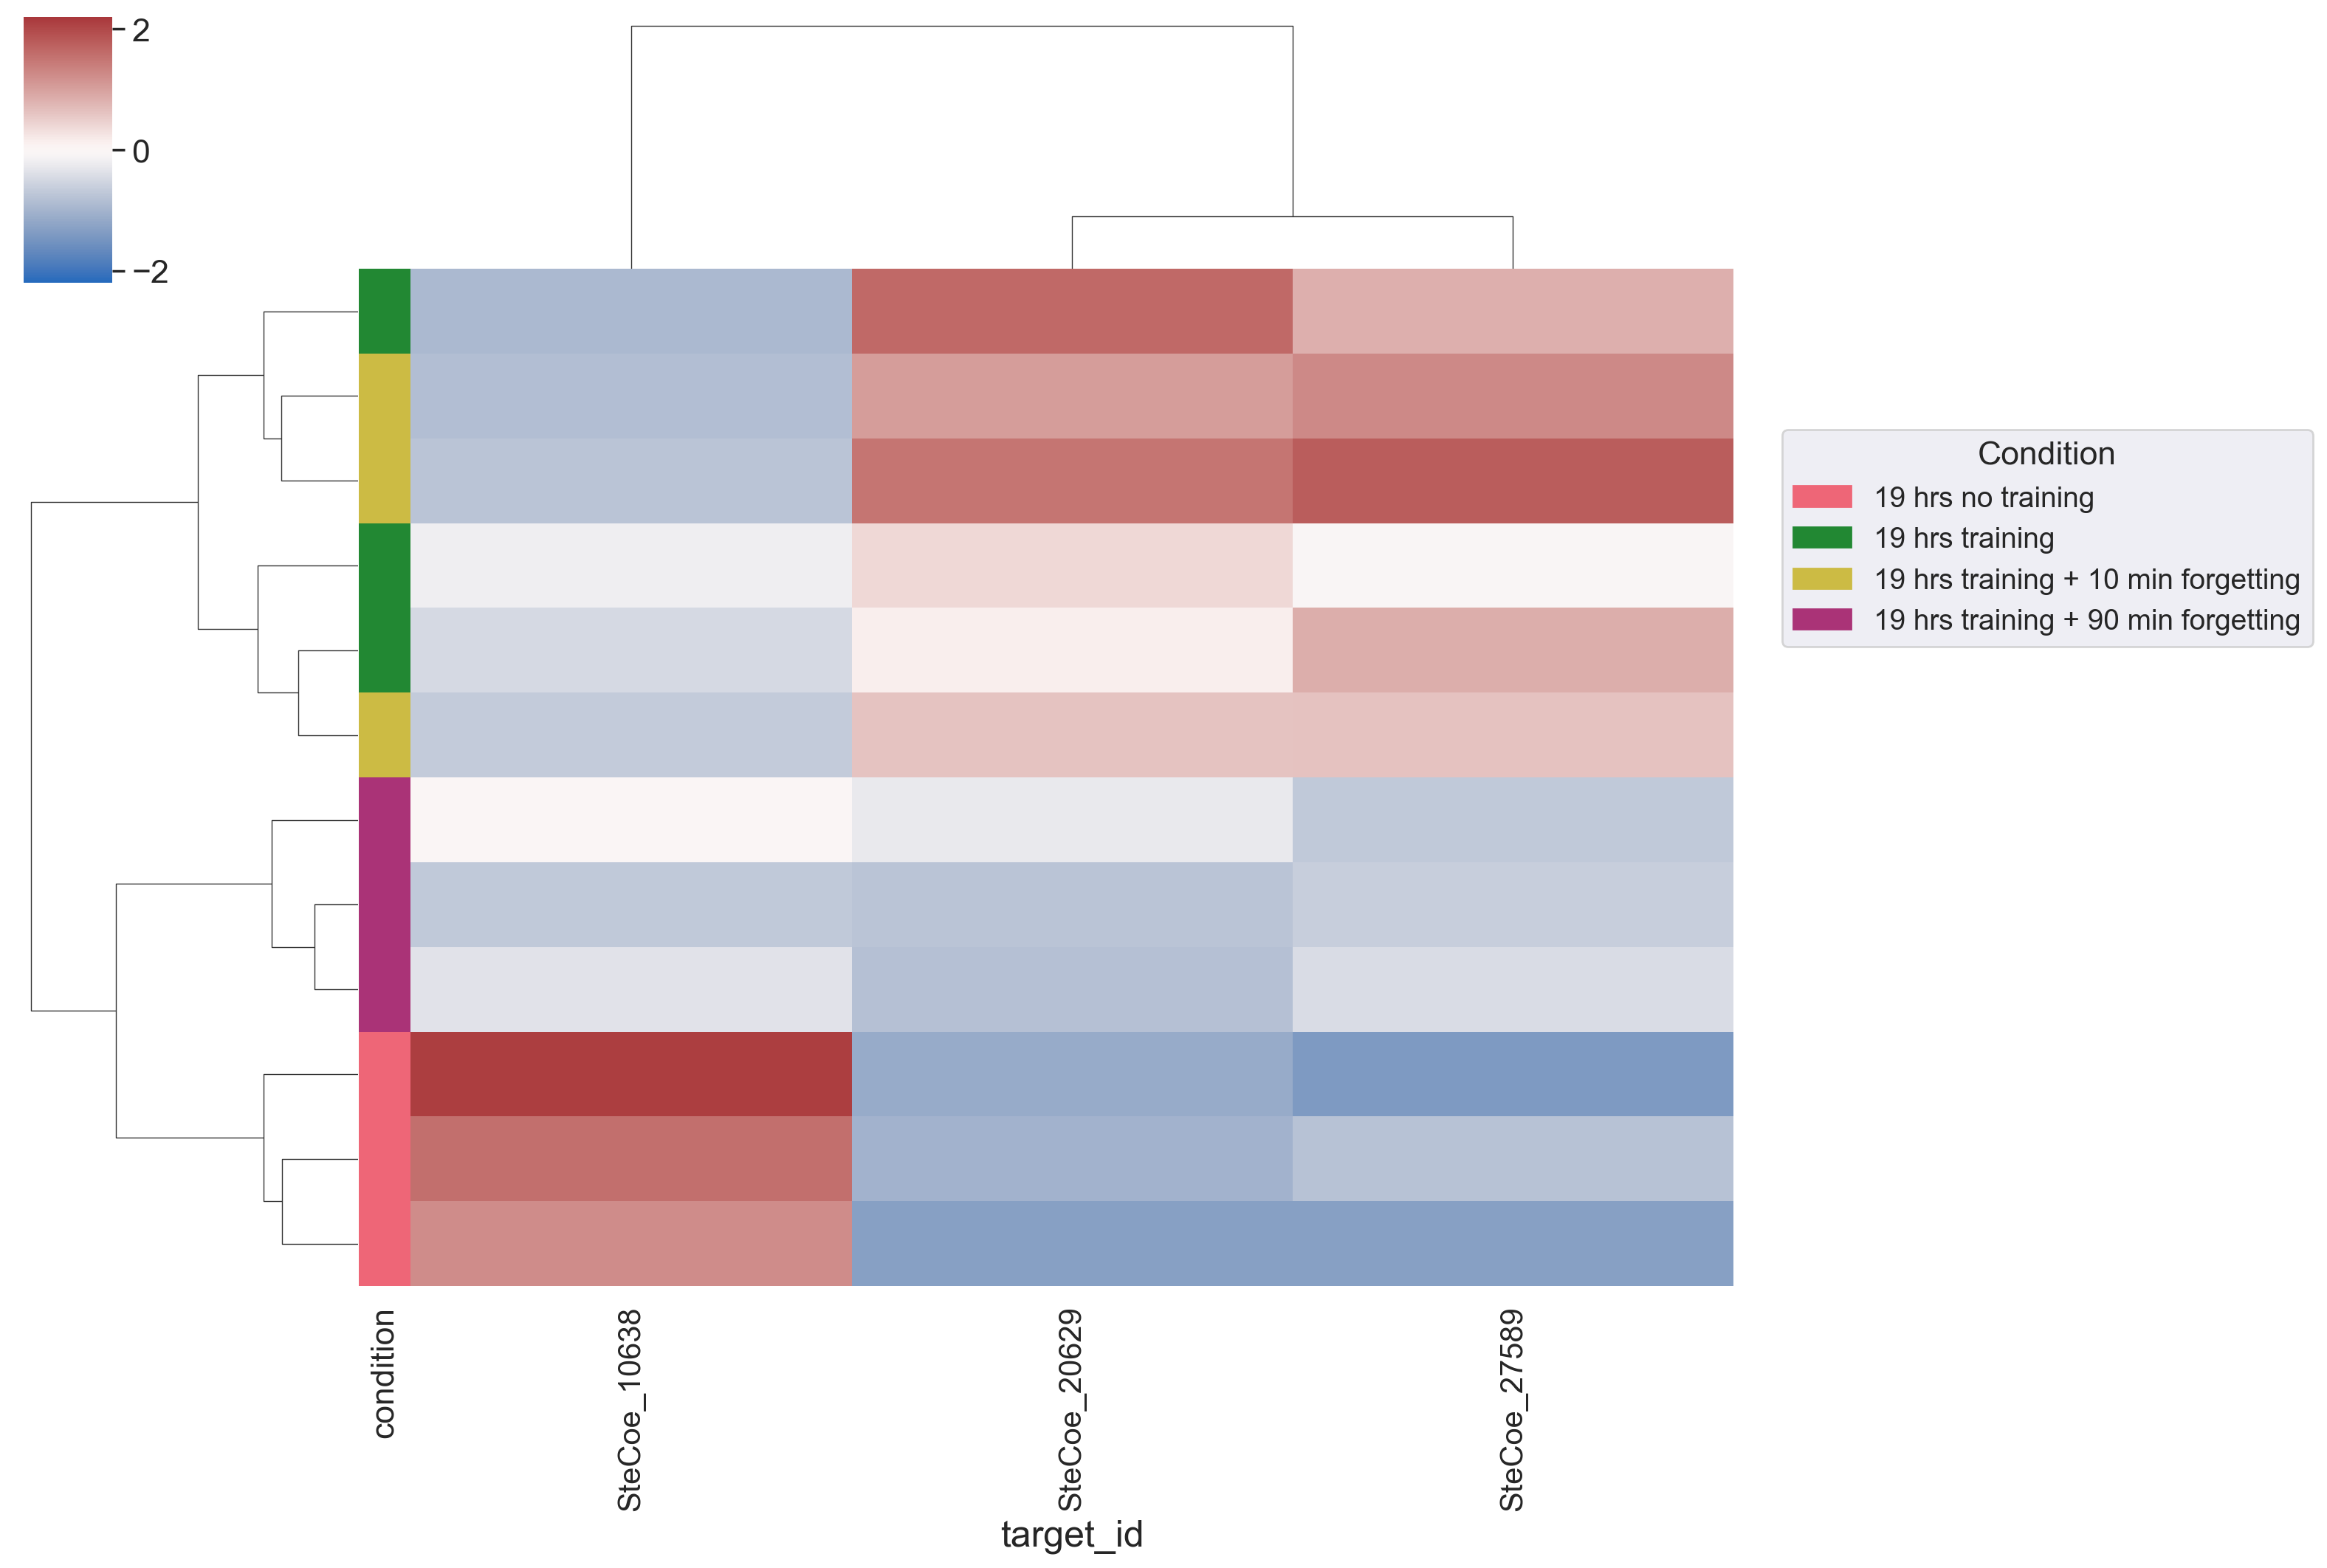

In [26]:
##### heatmap of top statistically significant

# get expression data 
top_50_gene_names_no0 = top_50_genes_no0.index
top_50_expr_no0 = df_no0.loc[top_50_gene_names_no0]

# z-score normalize
top_50_expr_zscore_no0 = top_50_expr_no0.apply(zscore, axis=1)

# map sample to color
row_colors = s2c_no0['condition'].map(color_dict)

# plot
g = sns.clustermap(
    top_50_expr_zscore_no0.T,  # samples as rows
    cmap="vlag",  # z-score colormap
    annot=False,  # don't need annot
    figsize=(12, 10),  # plot size
    row_colors=row_colors,  # color rows based on condition
    xticklabels = True, # show all genes?
    yticklabels = False, # show all samples? 
    vmin = -2.2, # set min max, center around 0 
    vmax = 2.2
)

# Adjust the colorbar label 
cbar = g.ax_cbar
cbar.set_label('Z-score Expression')  # Set the label first
cbar.yaxis.label.set_fontsize(14) 

# condition legend
handles = [mpatches.Patch(color=color_dict_no0[condition], label=condition) for condition in color_dict_no0]

# condition legend and position relative to z-score colorbar
handles = [mpatches.Patch(color=color_dict_no0[key], label=label_dict_no0[key]) for key in color_dict_no0]
plt.legend(handles=handles, title="Condition", bbox_to_anchor=(26, -0.5), loc='upper right', fontsize = 14, title_fontsize = 16)

# gene font angle and size 
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=15)  

# save
plt.savefig("exp2_RNA_hm_obsnorm_zscore_no0.png", dpi=300, bbox_inches='tight')

# show
plt.show()


## Heatmap of top 50 by unadjusted p-values 

In [27]:
top_50_genes_no0 = stat_df_no0[stat_df_no0.qval < 1].sort_values('pval').head(50)

In [28]:
top_50_genes_no0

,Unnamed: 0,pval,qval,test_stat,rss,degrees_free,mean_obs,var_obs,tech_var,sigma_sq,smooth_sigma_sq,final_sigma_sq
target_id,,,,,,,,,,,,
SteCoe_20629,2,0.000010,0.152824,25.923525,1.490043,3.0,7.019032,0.135458,0.000866,0.134593,0.009288,0.134593
SteCoe_10638,1,0.000011,0.152824,25.667060,1.756714,3.0,4.784889,0.159701,0.009509,0.150192,0.015033,0.150192
SteCoe_27589,3,0.000031,0.281000,23.558522,0.915347,3.0,5.070506,0.083213,0.006415,0.076799,0.013076,0.076799
SteCoe_32936,4,0.000047,0.317487,22.704928,1.312208,3.0,5.141393,0.119292,0.007166,0.112126,0.012677,0.112126
SteCoe_20170,5,0.000059,0.321447,22.213703,0.637586,3.0,6.146614,0.057962,0.002002,0.055961,0.009682,0.055961
SteCoe_9692,6,0.000090,0.411090,21.319345,0.414435,3.0,6.309553,0.037676,0.001689,0.035987,0.009496,0.035987
SteCoe_23659,10,0.000139,0.415526,20.421808,2.459326,3.0,4.419751,0.223575,0.014535,0.209040,0.018538,0.209040
SteCoe_14192,9,0.000140,0.415526,20.400894,0.503847,3.0,7.510127,0.045804,0.000434,0.045370,0.009318,0.045370
SteCoe_3429,7,0.000142,0.415526,20.379051,0.793050,3.0,6.439036,0.072095,0.001674,0.070422,0.009402,0.070422


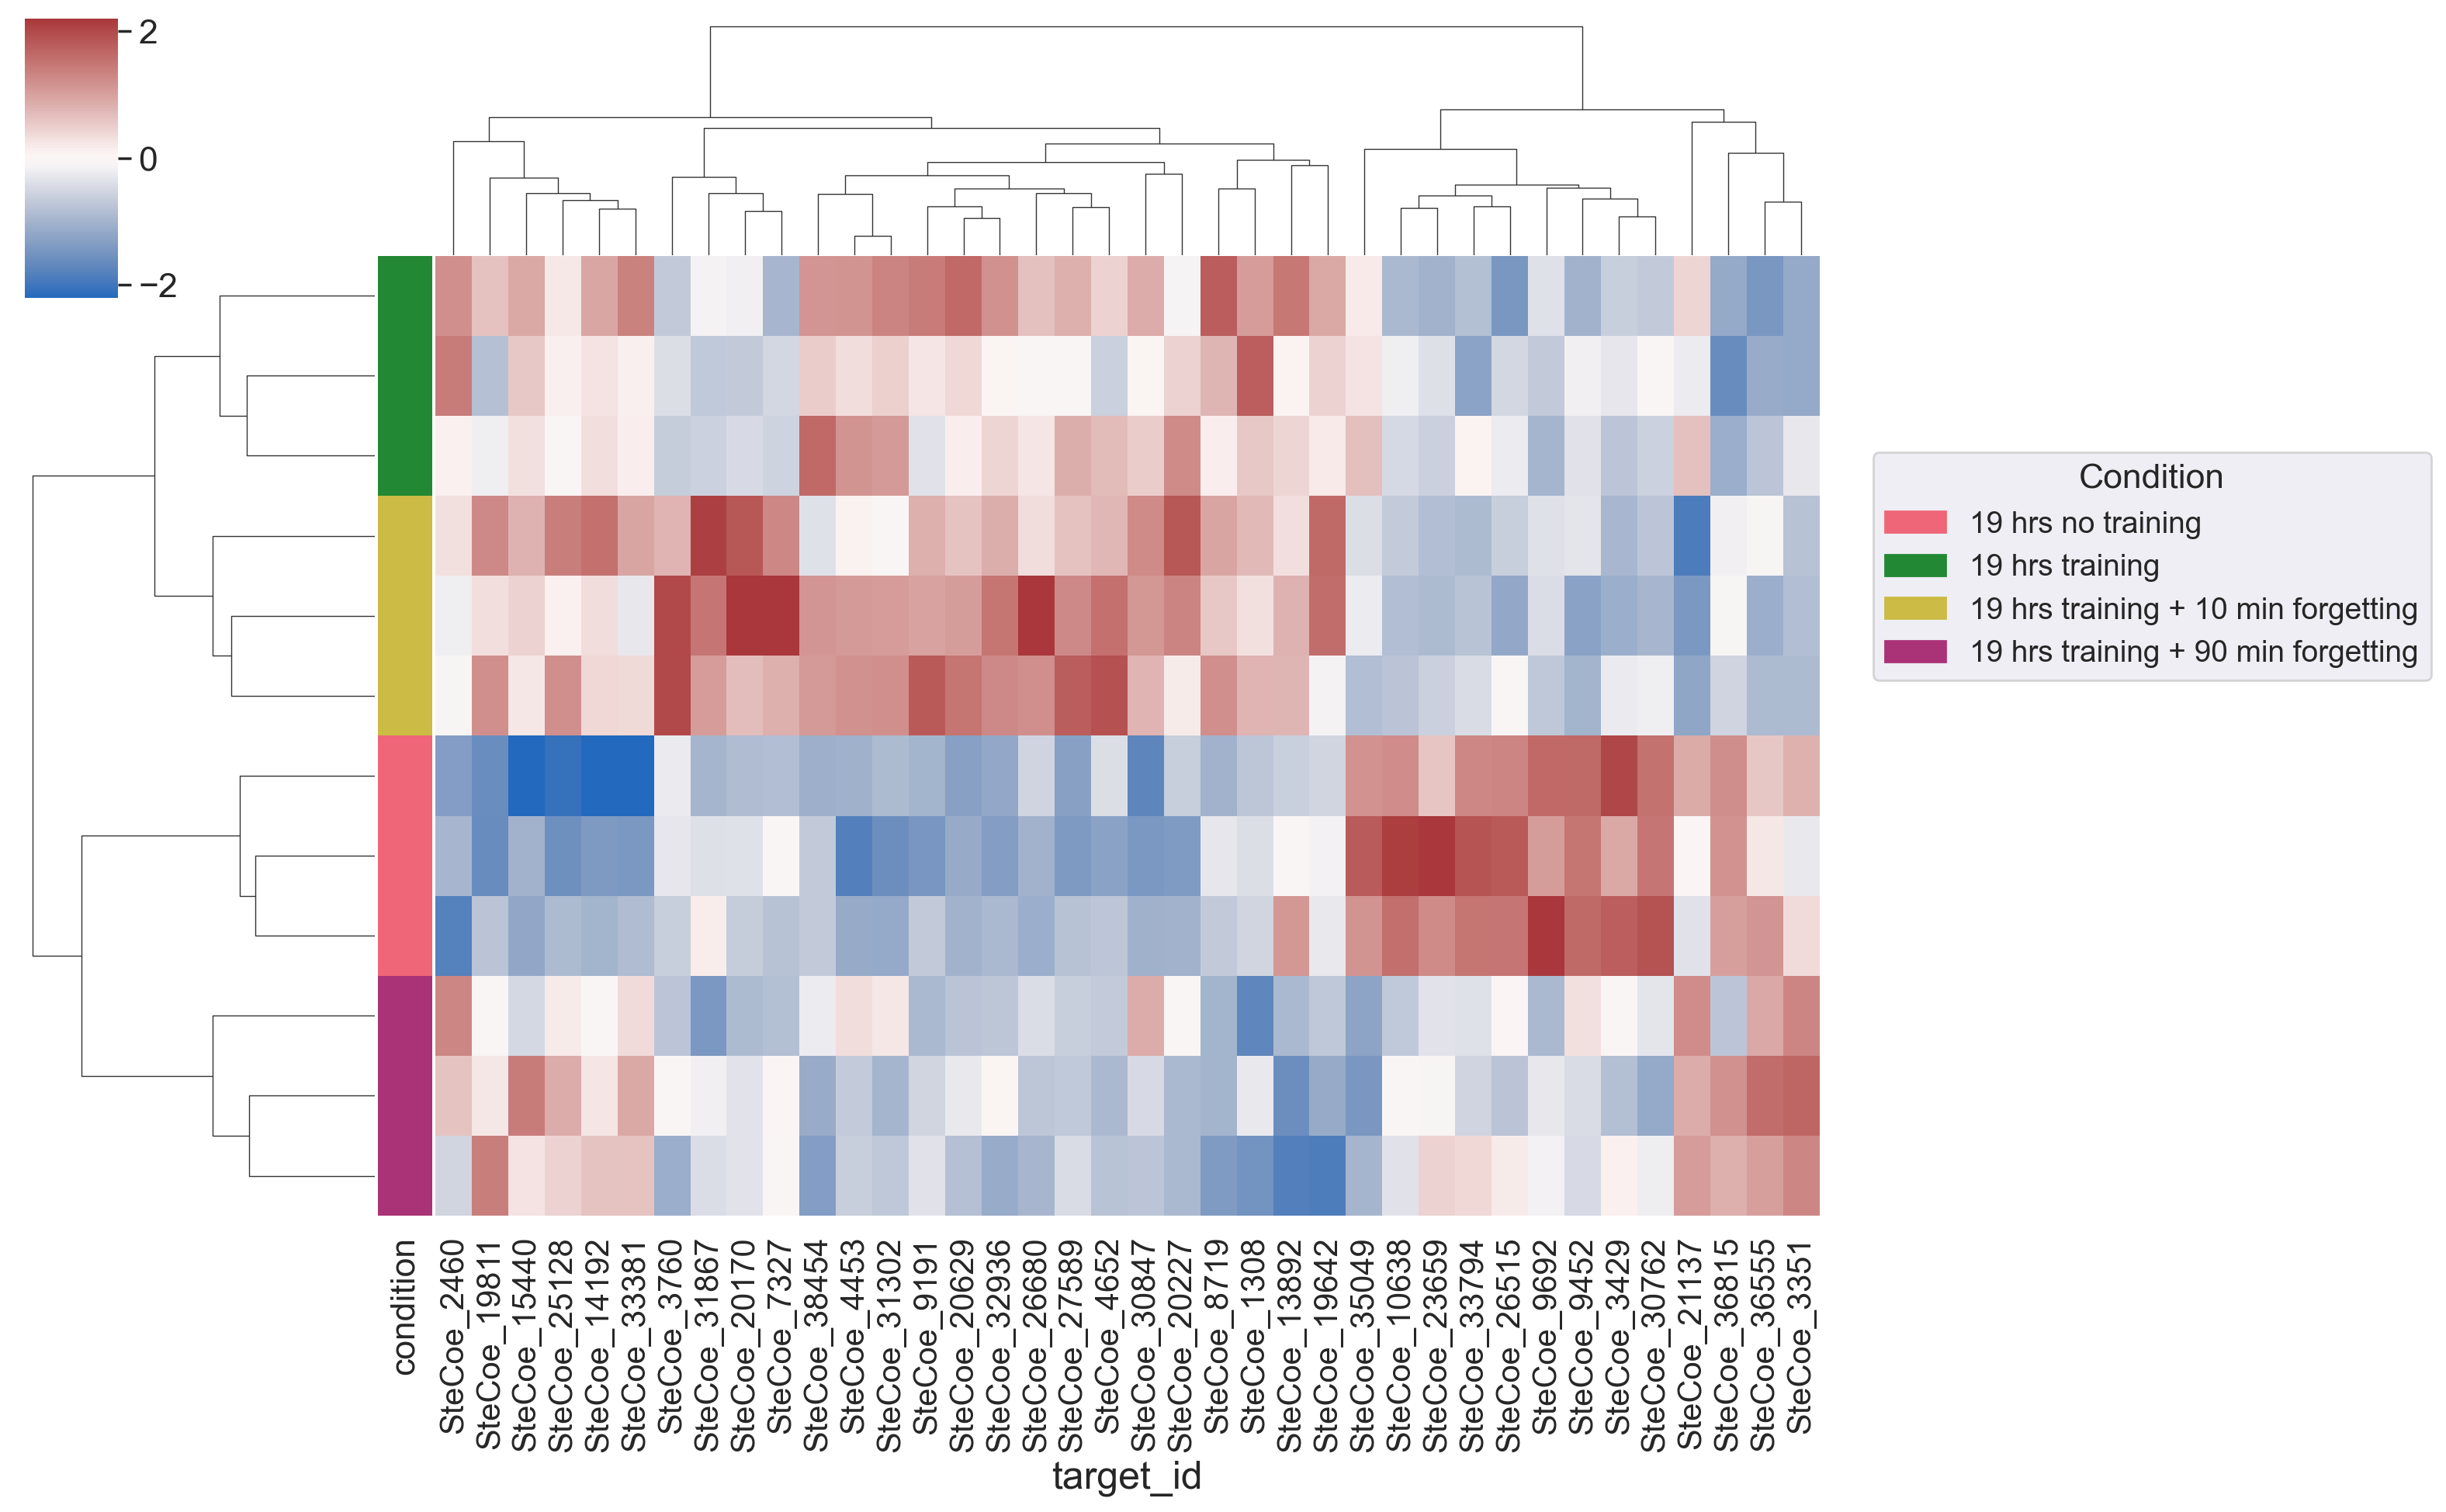

In [29]:
##### heatmap of top statistically significant

# get expression data 
top_50_gene_names_no0 = top_50_genes_no0.index
top_50_expr_no0 = df_no0.loc[top_50_gene_names_no0]

# z-score normalize
top_50_expr_zscore_no0 = top_50_expr_no0.apply(zscore, axis=1)

# map sample to color
row_colors = s2c_no0['condition'].map(color_dict)

# plot
g = sns.clustermap(
    top_50_expr_zscore_no0.T,  # samples as rows
    cmap="vlag",  # z-score colormap
    annot=False,  # don't need annot
    figsize=(12, 10),  # plot size
    row_colors=row_colors,  # color rows based on condition
    xticklabels = True, # show all genes?
    yticklabels = False, # show all samples? 
    vmin = -2.2, # set min max, center around 0 
    vmax = 2.2
)

# Adjust the colorbar label 
cbar = g.ax_cbar
cbar.set_label('Z-score Expression')  # Set the label first
cbar.yaxis.label.set_fontsize(14) 

# condition legend
handles = [mpatches.Patch(color=color_dict_no0[condition], label=condition) for condition in color_dict_no0]

# condition legend and position relative to z-score colorbar
handles = [mpatches.Patch(color=color_dict_no0[key], label=label_dict_no0[key]) for key in color_dict_no0]
plt.legend(handles=handles, title="Condition", bbox_to_anchor=(26, -0.5), loc='upper right', fontsize = 14, title_fontsize = 16)

# gene font angle and size 
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=15)  

# save
plt.savefig("exp2_RNA_hm_obsnorm_zscore_pval_no0.png", dpi=300, bbox_inches='tight')

# show
plt.show()


### Single-gene plots

In [30]:
# specific gene
specific_gene = 'SteCoe_36075'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

In [31]:
specific_gene_expr_df

,sample,expression,condition_x,condition_y
0,DR4876_01,36.638870,19 hrs training,t_19
1,DR4876_02,17.434449,time 0,t_0
2,DR4876_03,29.184353,19 hrs no training,ut_19
3,DR4876_04,37.290823,19 hrs training,t_19
4,DR4876_05,28.989996,time 0,t_0
5,DR4876_06,26.895560,19 hrs no training,ut_19
6,DR4876_07,30.113635,19 hrs training,t_19
7,DR4876_08,32.628977,time 0,t_0
8,DR4876_09,30.905901,19 hrs no training,ut_19
9,DR4876_10,26.231484,19 hrs training + 10 min forgetting,f_10


In [32]:
specific_gene_expr_df = specific_gene_expr_df.replace(np.nan, 'time 0', regex=True)

In [33]:
# Remap color_dict_no0 to match the new condition labels
color_dict_named = {label_dict[k]: v for k, v in color_dict.items() if k in label_dict}

In [34]:
color_dict_named

{'time 0': '#4477AA',
 '19 hrs no training': '#EE6677',
 '19 hrs training': '#228833',
 '19 hrs training + 10 min forgetting': '#CCBB44',
 '19 hrs training + 90 min forgetting': '#AA3377'}

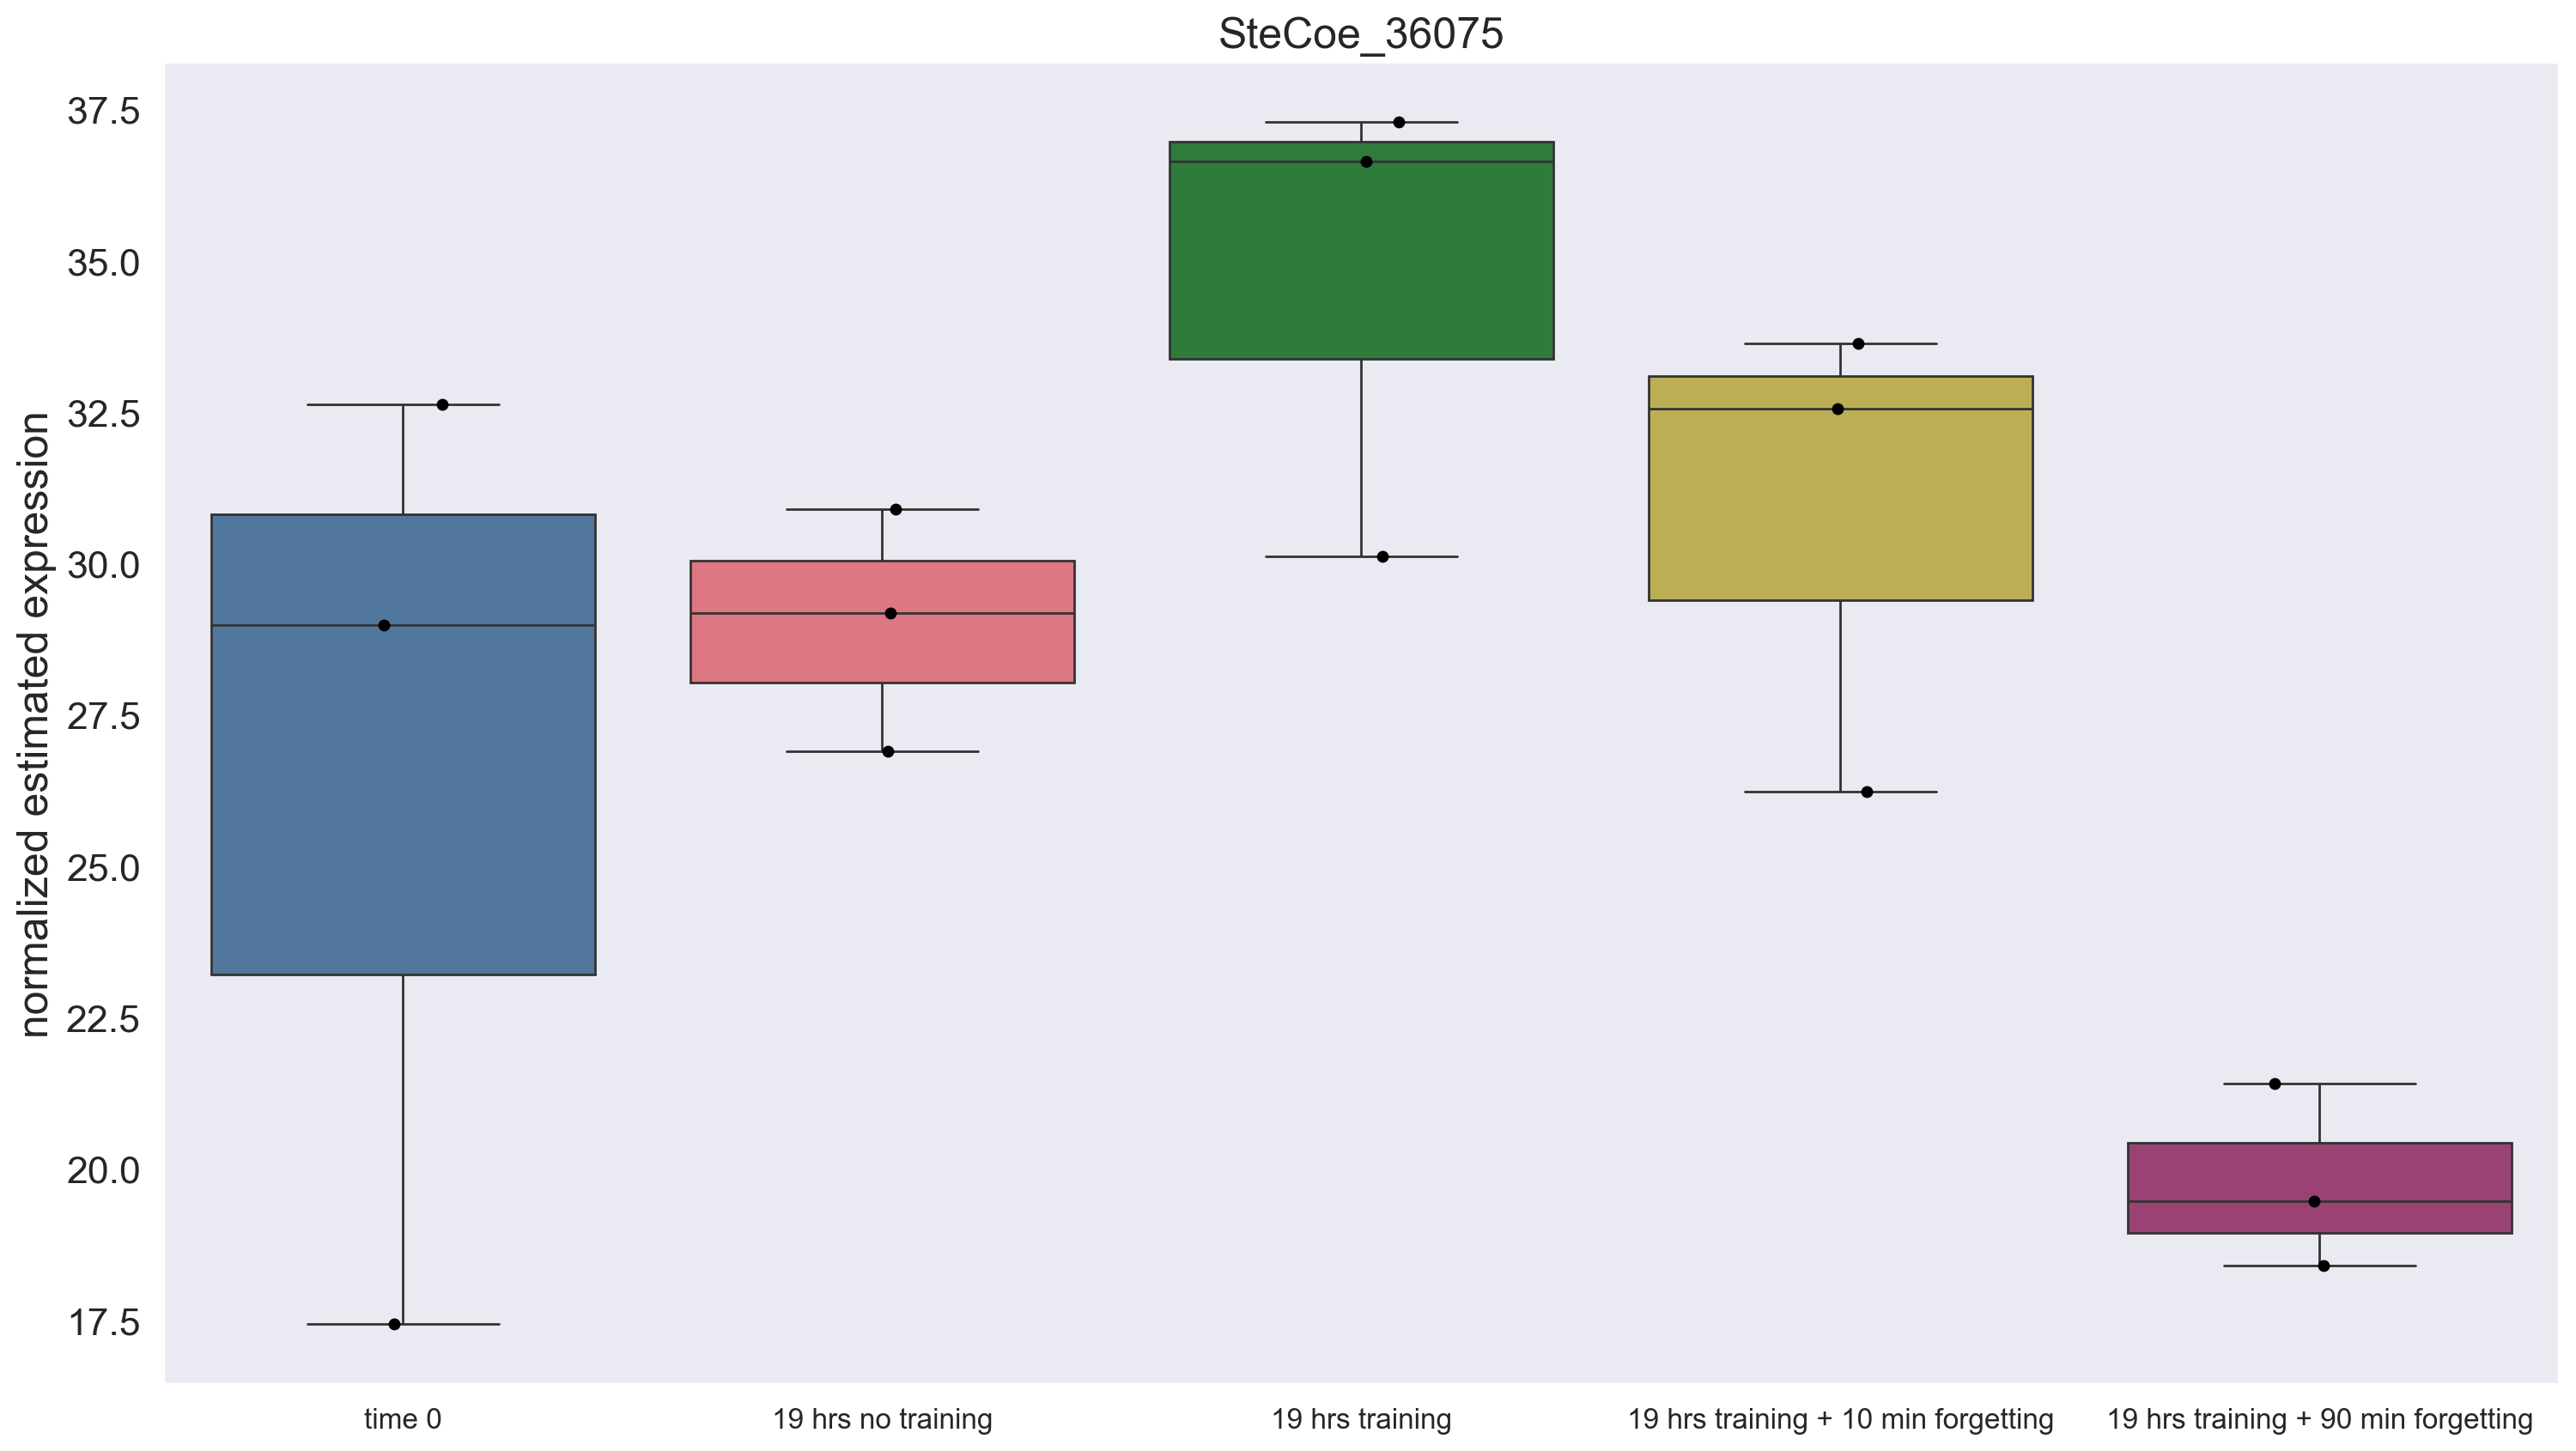

In [35]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("normalized estimated expression", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_rna_36075.png', dpi= 300, bbox_inches = 'tight')

In [36]:
specific_gene_expr_df

,sample,expression,condition_x,condition_y
0,DR4876_01,36.638870,19 hrs training,t_19
1,DR4876_02,17.434449,time 0,t_0
2,DR4876_03,29.184353,19 hrs no training,ut_19
3,DR4876_04,37.290823,19 hrs training,t_19
4,DR4876_05,28.989996,time 0,t_0
5,DR4876_06,26.895560,19 hrs no training,ut_19
6,DR4876_07,30.113635,19 hrs training,t_19
7,DR4876_08,32.628977,time 0,t_0
8,DR4876_09,30.905901,19 hrs no training,ut_19
9,DR4876_10,26.231484,19 hrs training + 10 min forgetting,f_10


In [37]:
# specific gene
specific_gene = 'SteCoe_10638'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

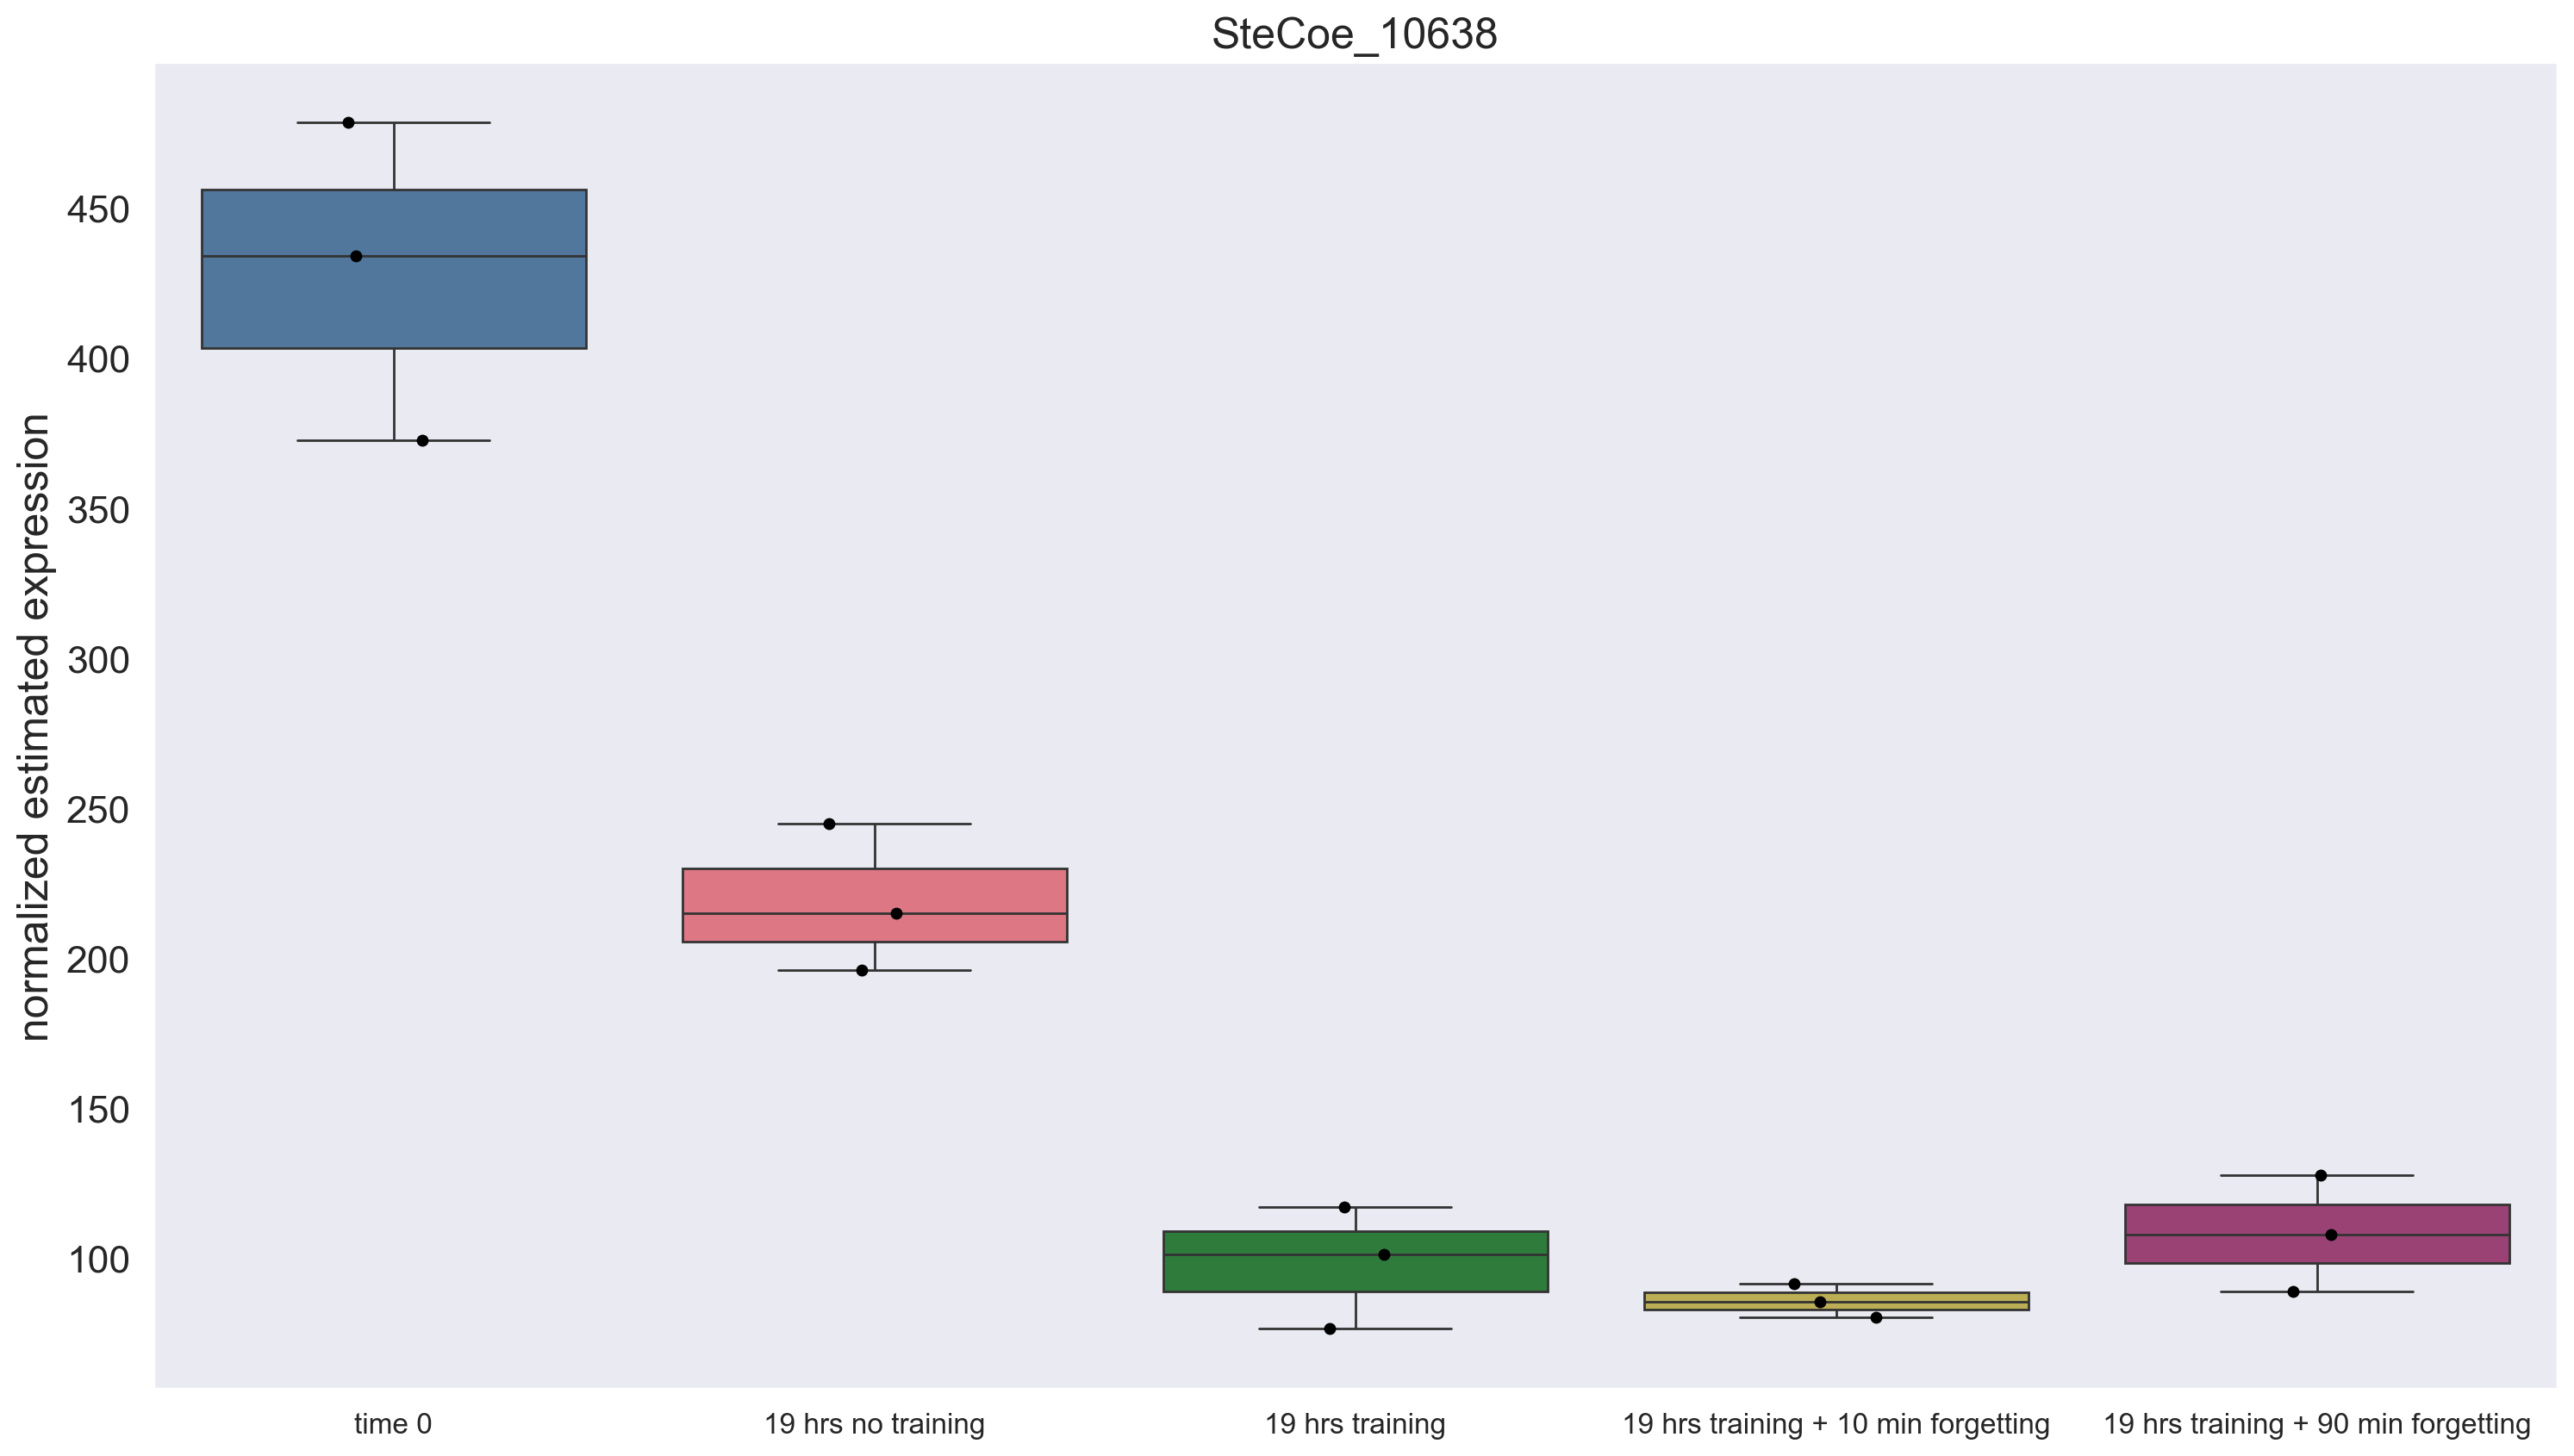

In [38]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("normalized estimated expression", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_rna_10638.png', dpi= 300, bbox_inches = 'tight')

In [39]:
# specific gene
specific_gene = 'SteCoe_34807'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

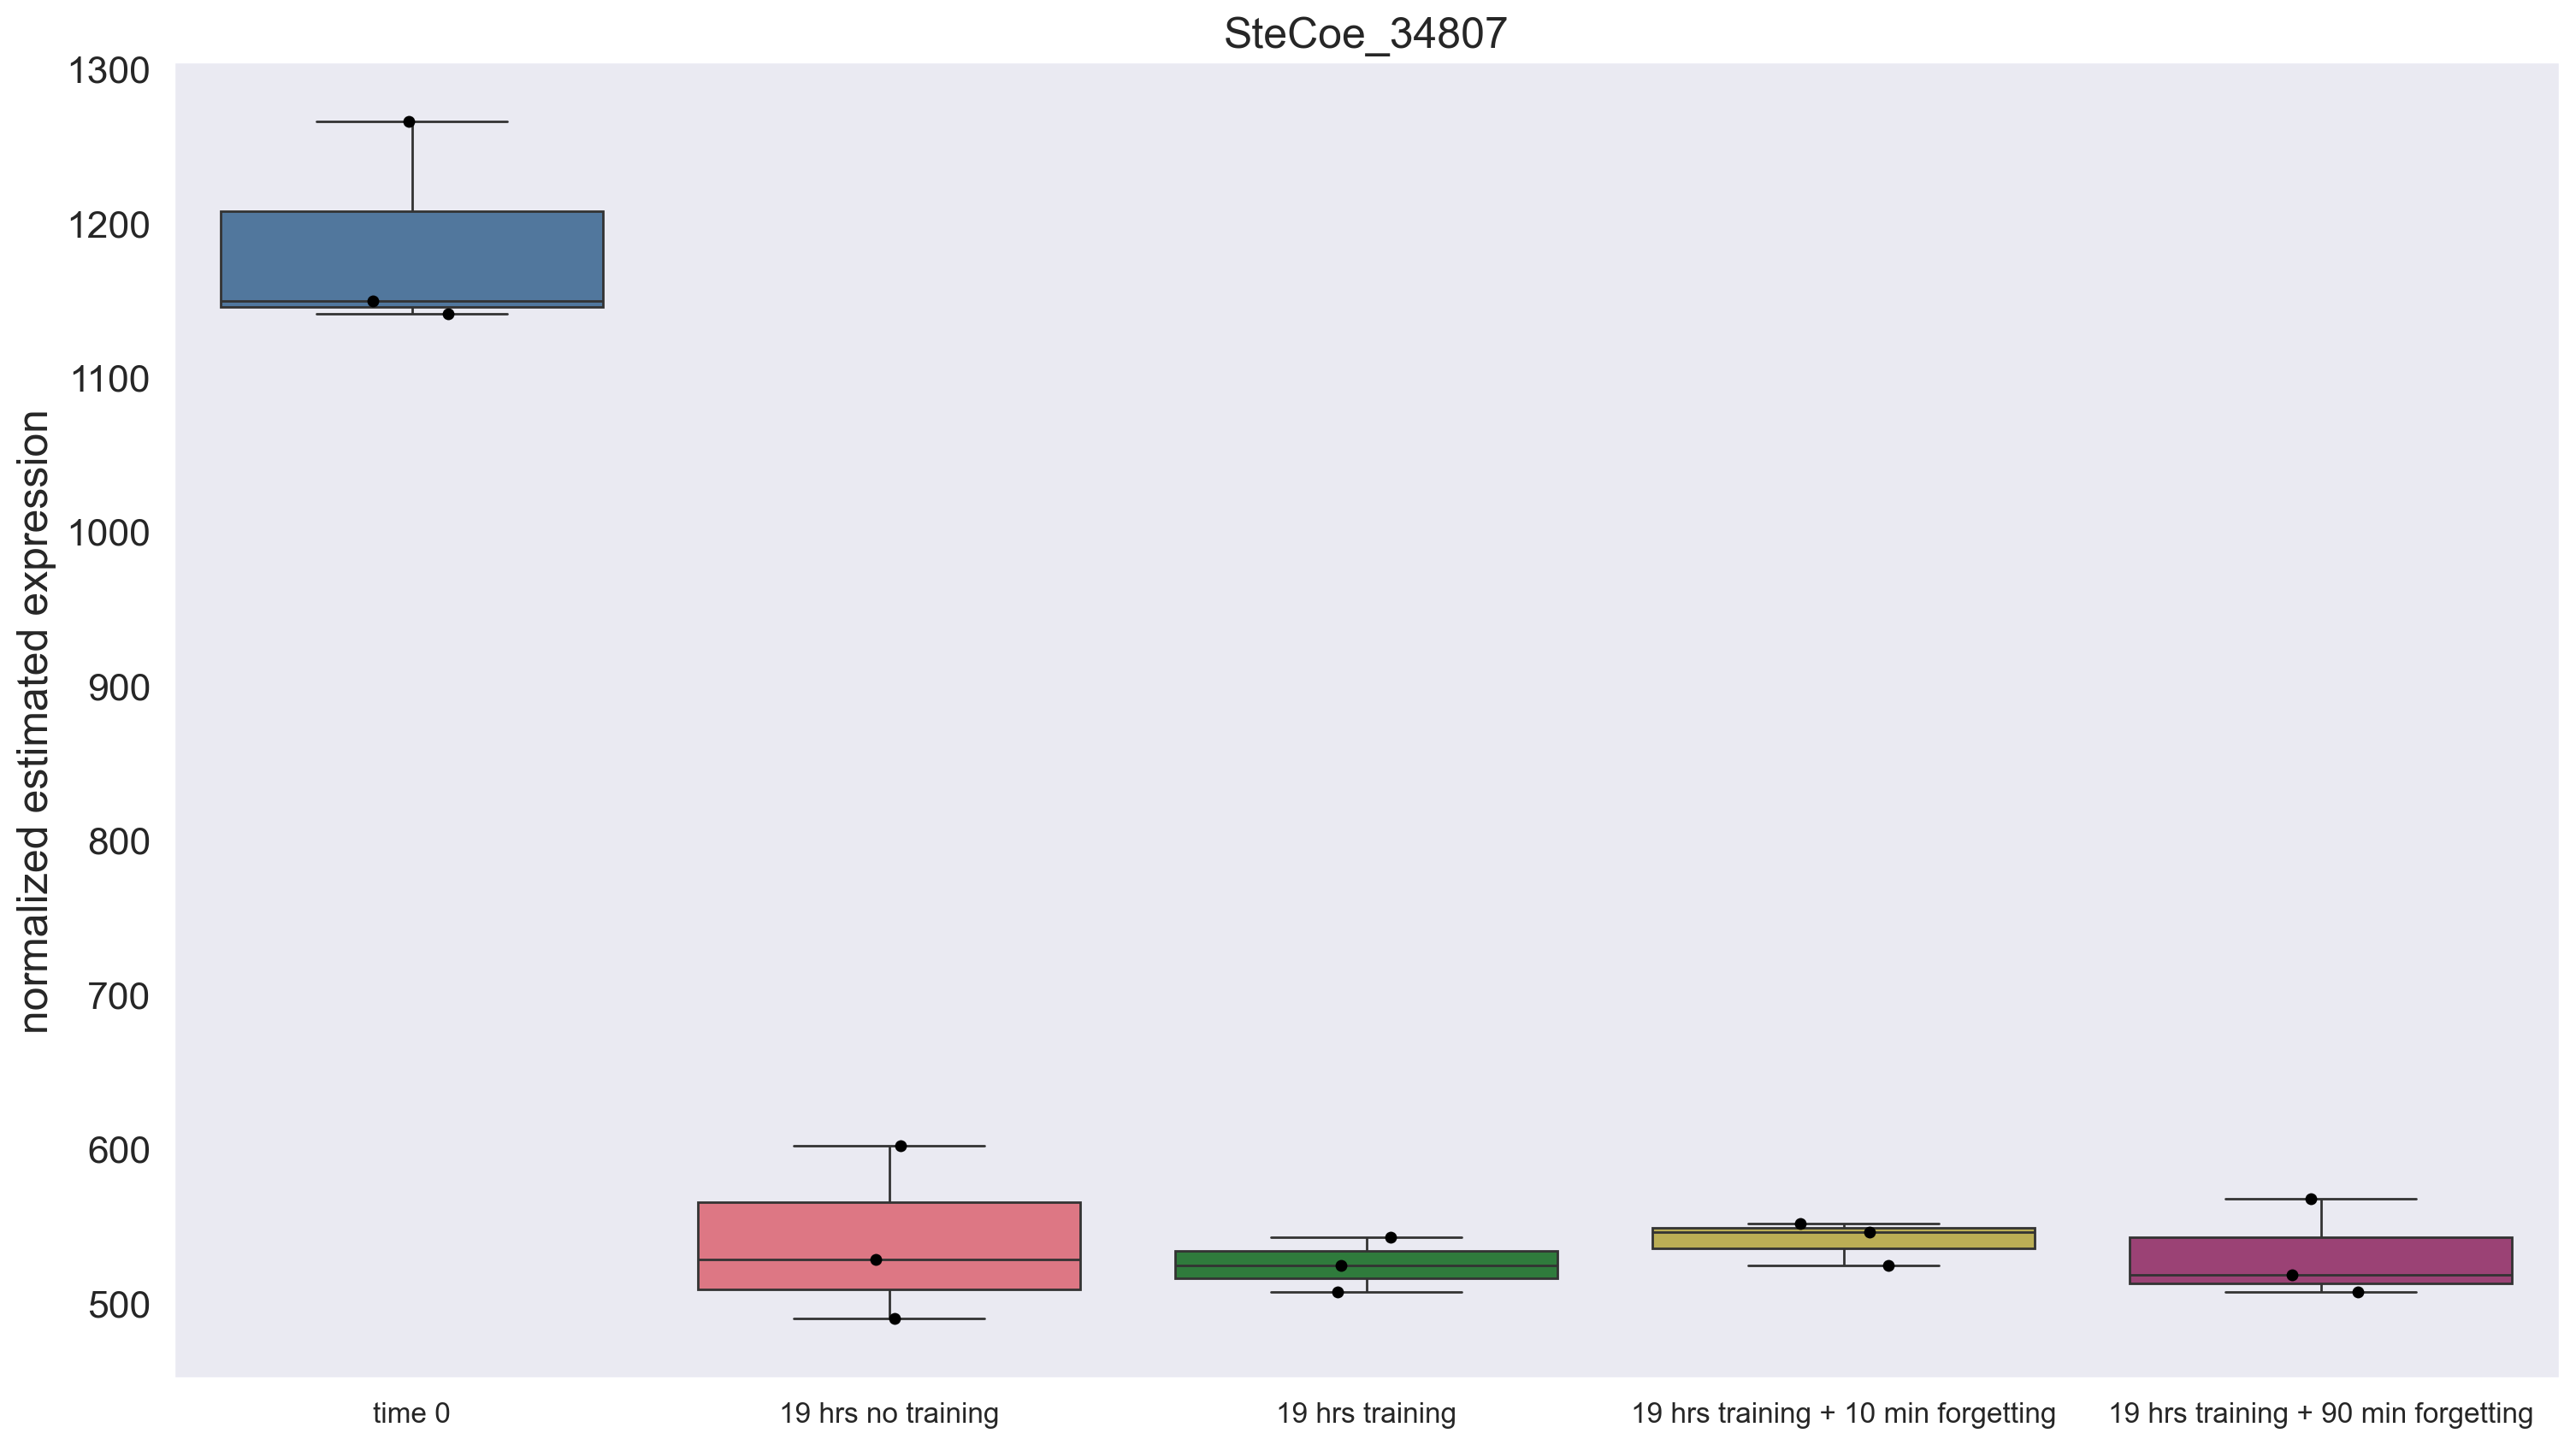

In [40]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("normalized estimated expression", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_rna_34807.png', dpi= 300, bbox_inches = 'tight')

In [41]:
# specific gene
specific_gene = 'SteCoe_26520'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

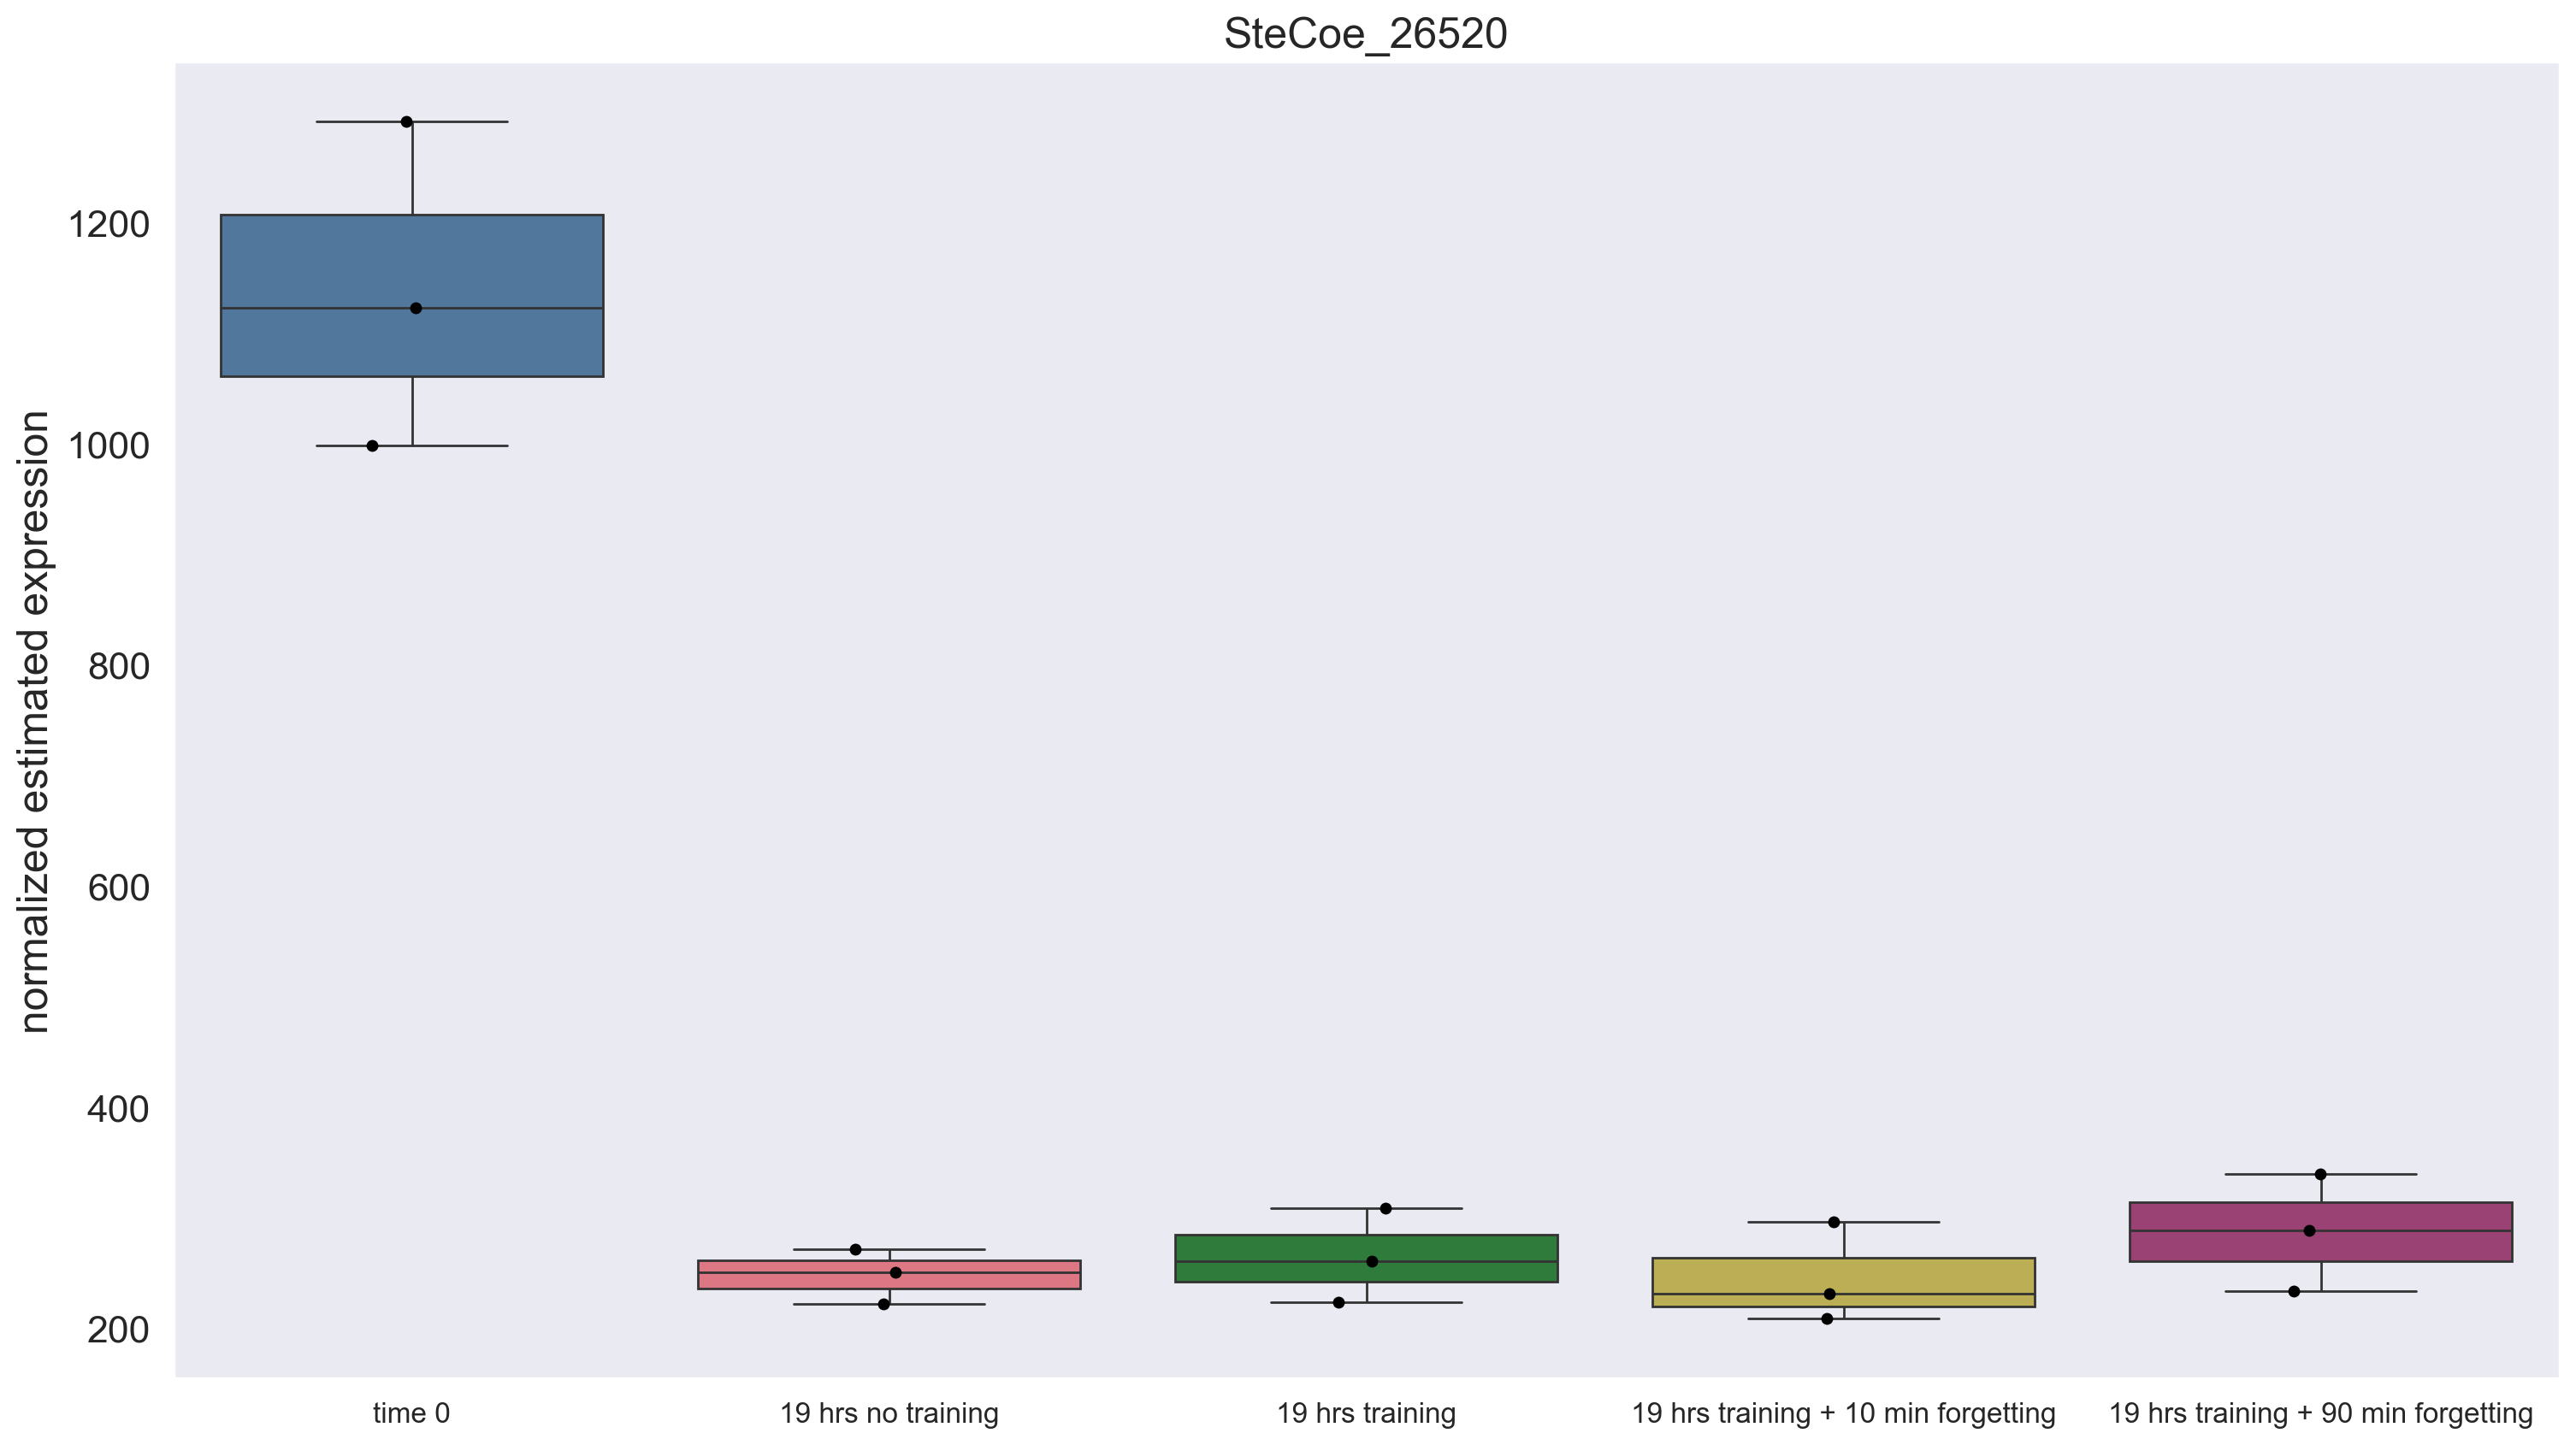

In [42]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("normalized estimated expression", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_rna_26520.png', dpi= 300, bbox_inches = 'tight')

In [43]:
# specific gene
specific_gene = 'SteCoe_20866'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

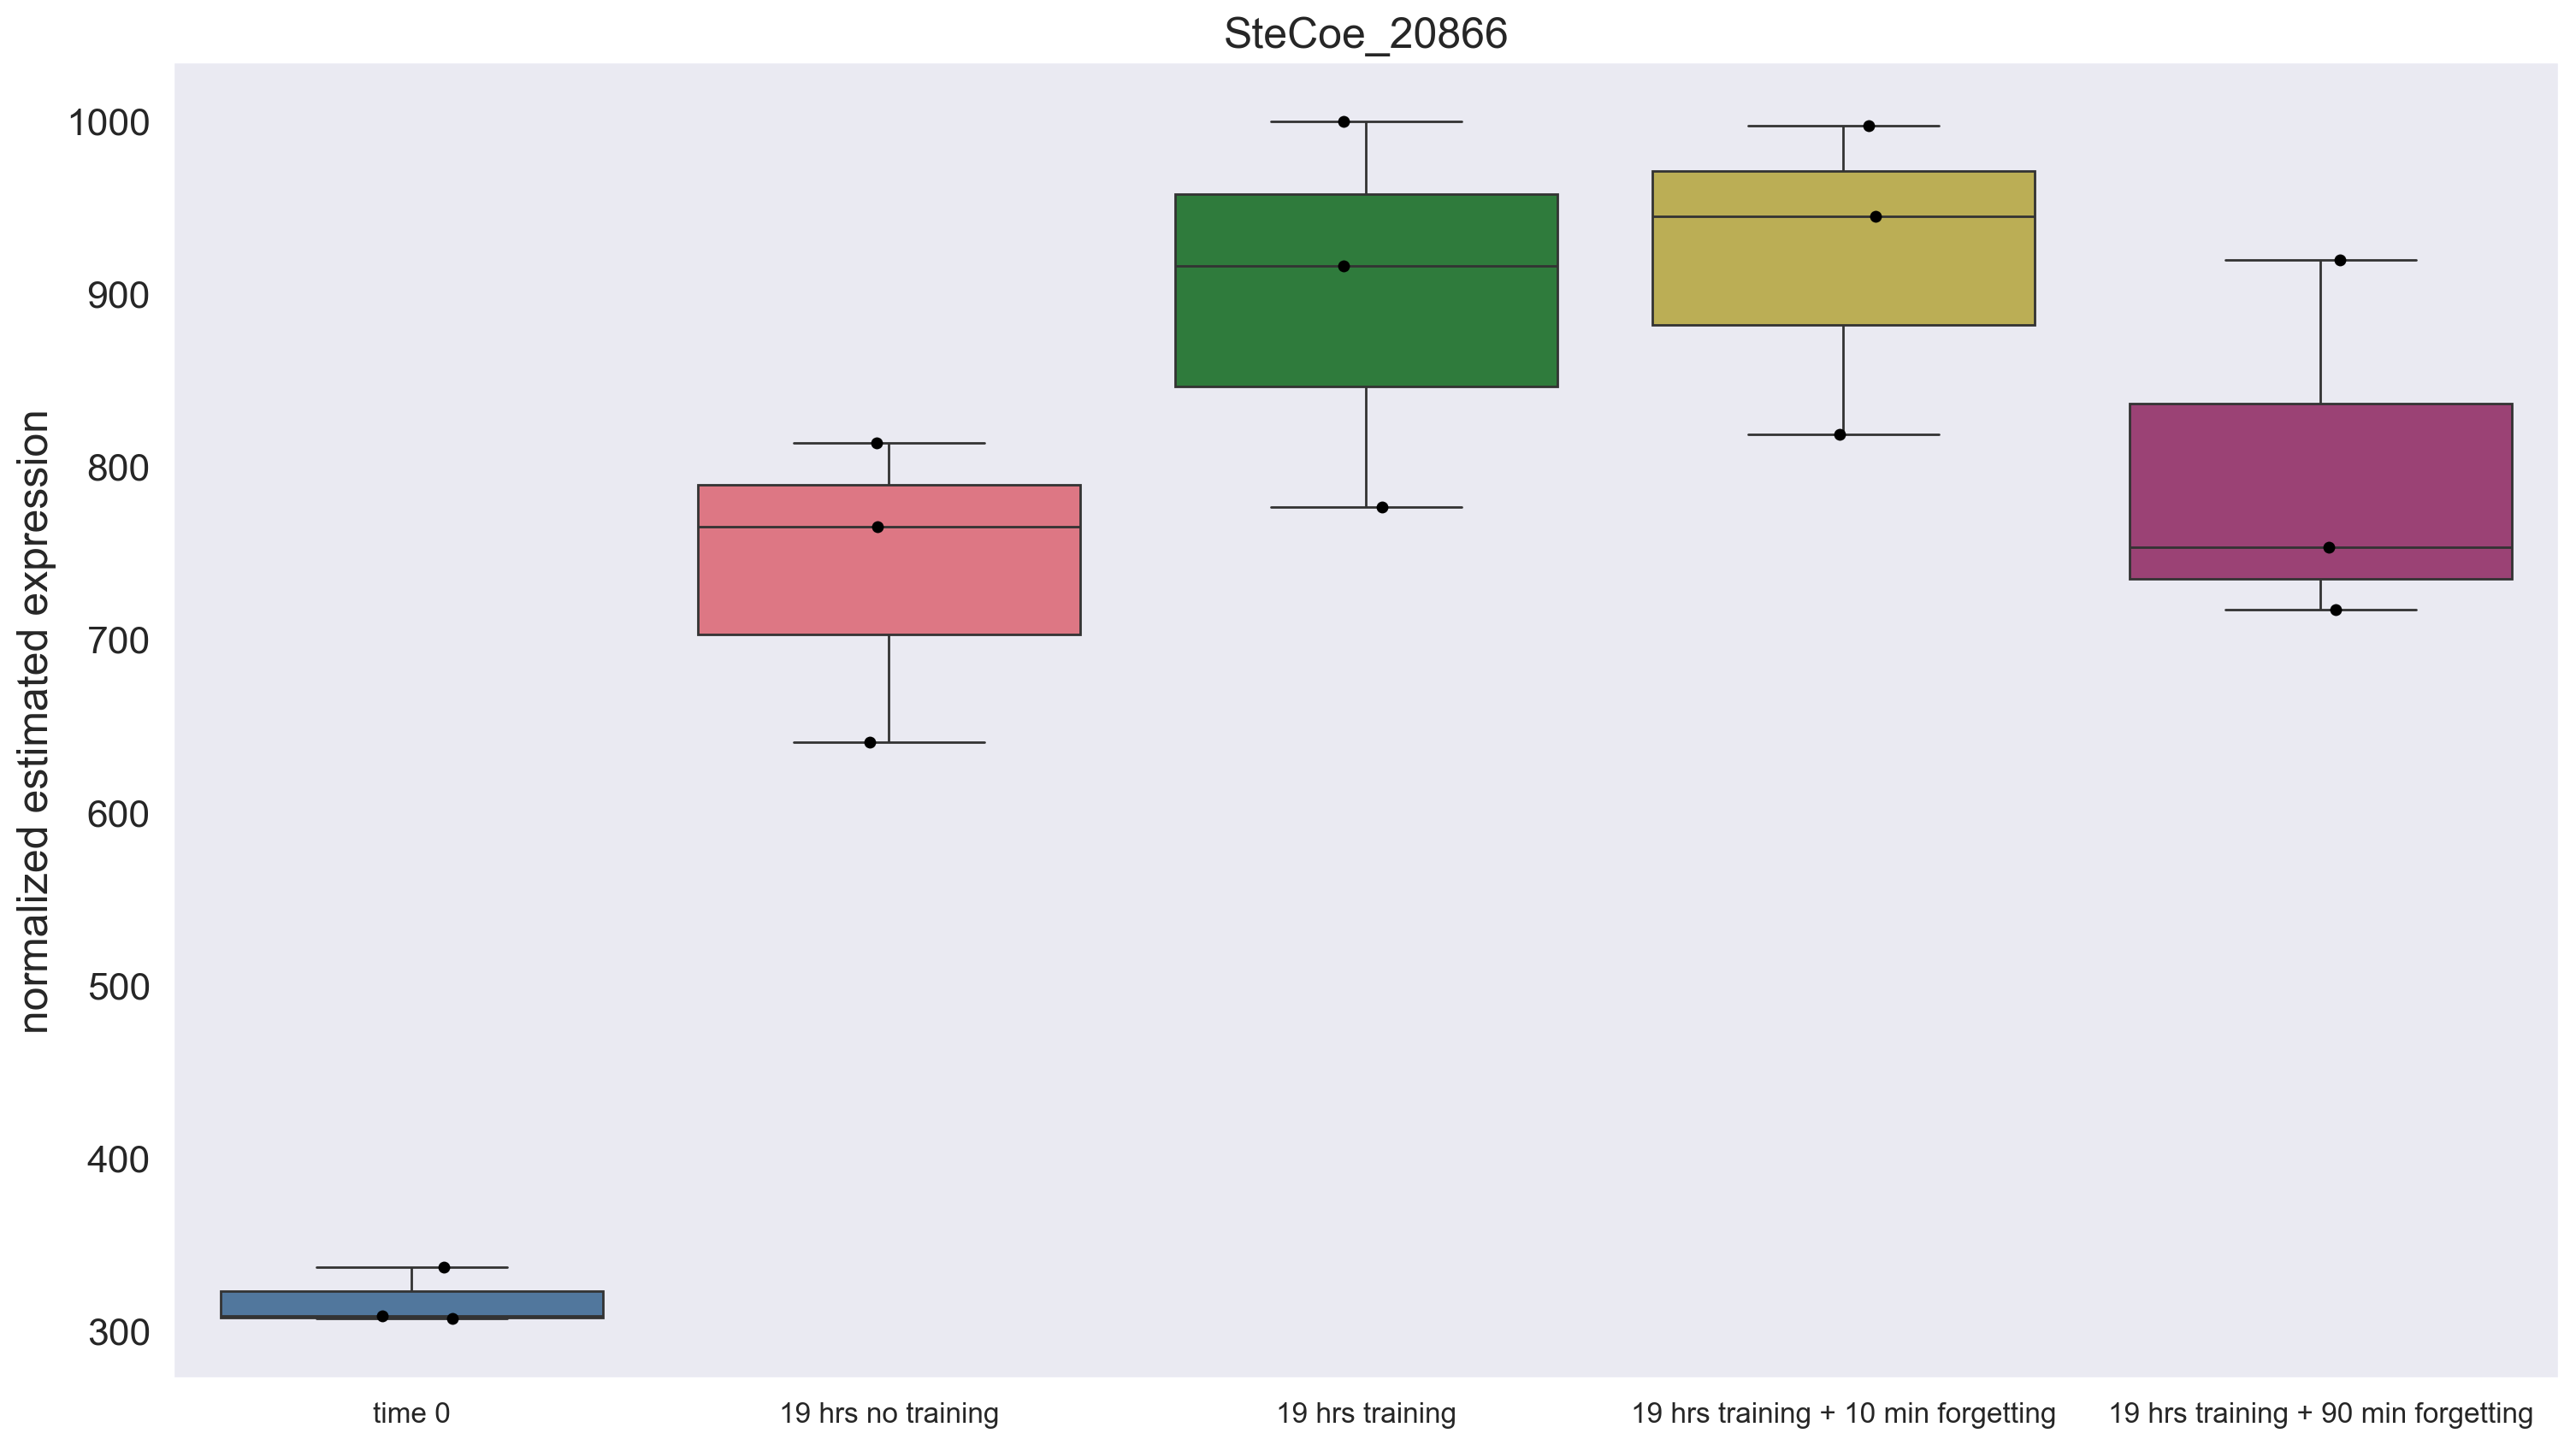

In [44]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("normalized estimated expression", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_rna_20866.png', dpi= 300, bbox_inches = 'tight')

In [45]:
# specific gene
specific_gene = 'SteCoe_9191'  # gene of interest
specific_gene_expr = df.loc[specific_gene]

# melt df 
specific_gene_expr_df = specific_gene_expr.reset_index()
specific_gene_expr_df.columns = ['sample', 'expression']

specific_gene_expr_df['condition'] = specific_gene_expr_df['sample'].map(s2c["condition"])
specific_gene_expr_df['condition'] = specific_gene_expr_df['condition'].map(label_dict)

# add label to df 
#specific_gene_expr_df['group'] = specific_gene_expr_df['condition'].map(new_labels)

# fix index
s2c_reset = s2c.reset_index()  # Reset the index so 'sample' becomes a column
specific_gene_expr_df = specific_gene_expr_df.merge(s2c_reset[['sample', 'condition']], on='sample')

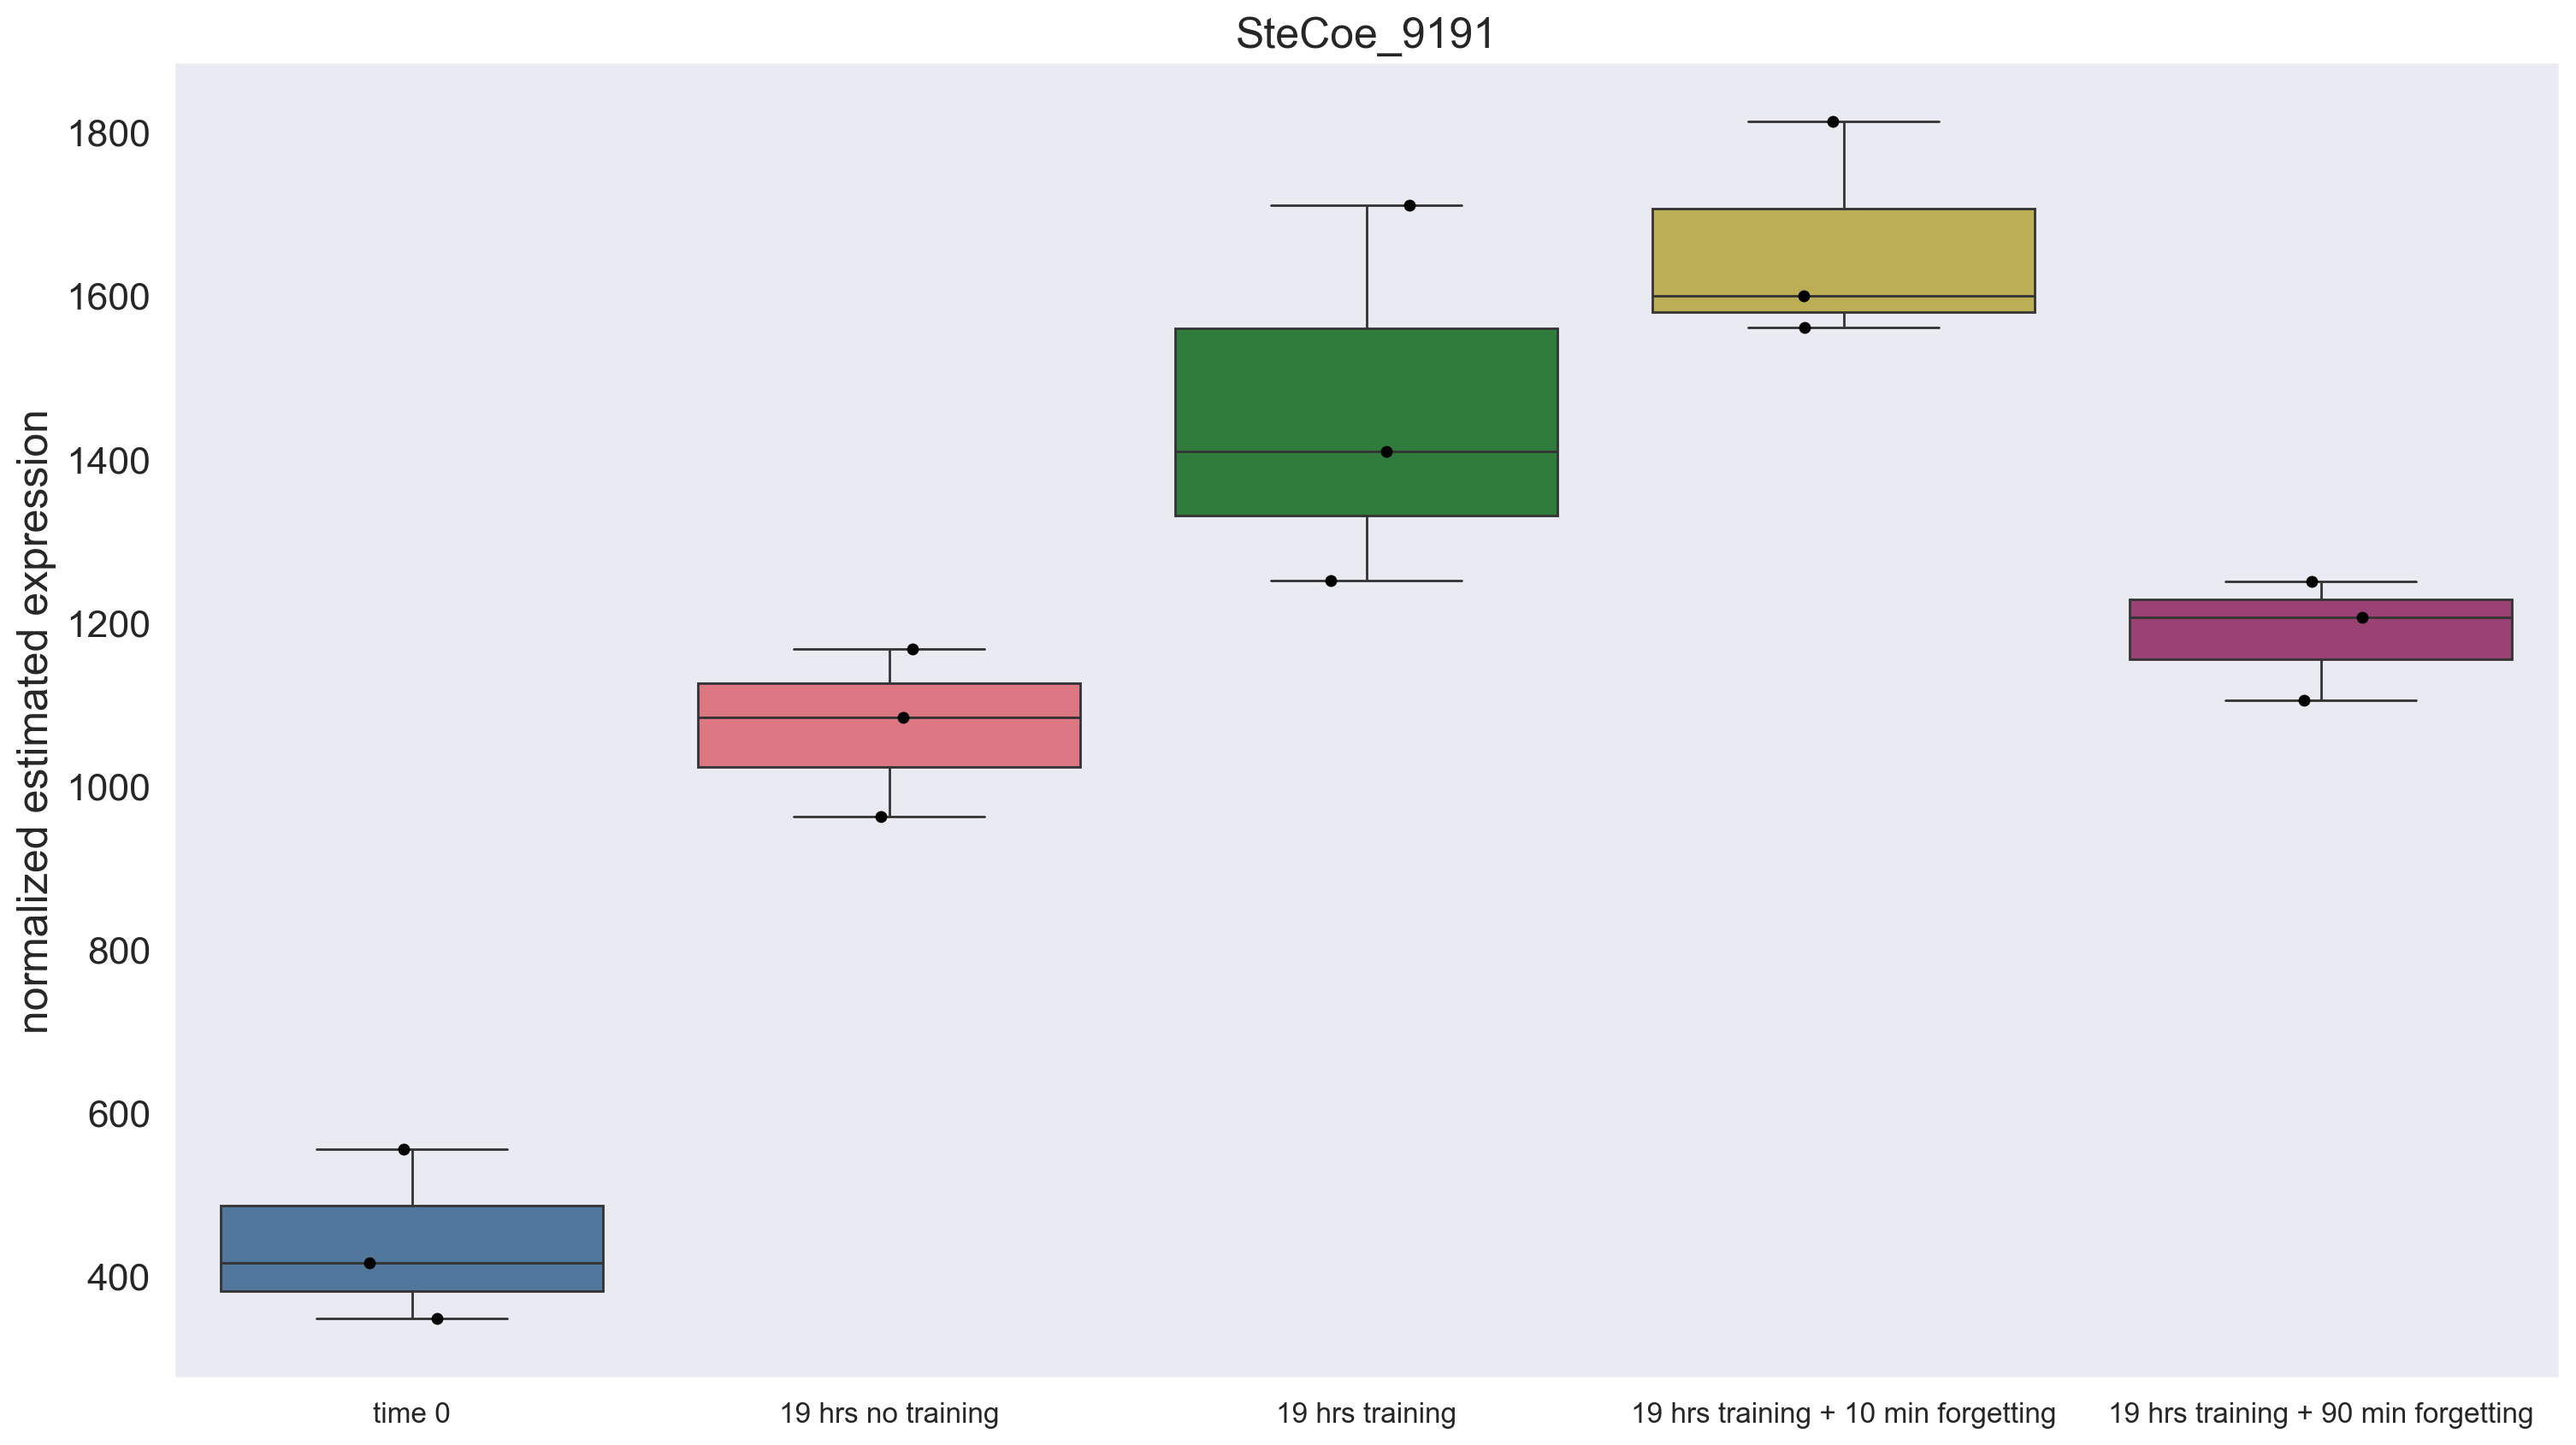

In [46]:
# plot

order = list(color_dict_named.keys())

plt.figure(figsize=(18, 10))
sns.boxplot(data=specific_gene_expr_df, 
            x="condition_x", 
            y="expression", 
            hue = 'condition_x', 
            palette = color_dict_named, 
            order = order)
sns.stripplot(x='condition_x', 
              y='expression', 
              data=specific_gene_expr_df, 
              color='black',
              order = order)
plt.xticks(fontsize=12)
plt.title(specific_gene)
plt.ylabel("normalized estimated expression", fontsize=18)
plt.xlabel("")
plt.savefig('exp2_rna_9191.png', dpi= 300, bbox_inches = 'tight')

### Volcano Plots

In [2]:
df_19 = pd.read_csv('/Volumes/albright_postdoc/deepa/exp2/exp2_rna_t19ut19_sleuth_wald_v2.csv').set_index('target_id')

In [4]:
gene_list = ['SteCoe_7377', 'SteCoe_20144', 'SteCoe_29027', 'SteCoe_16503', 'SteCoe_20070', 'SteCoe_10638']

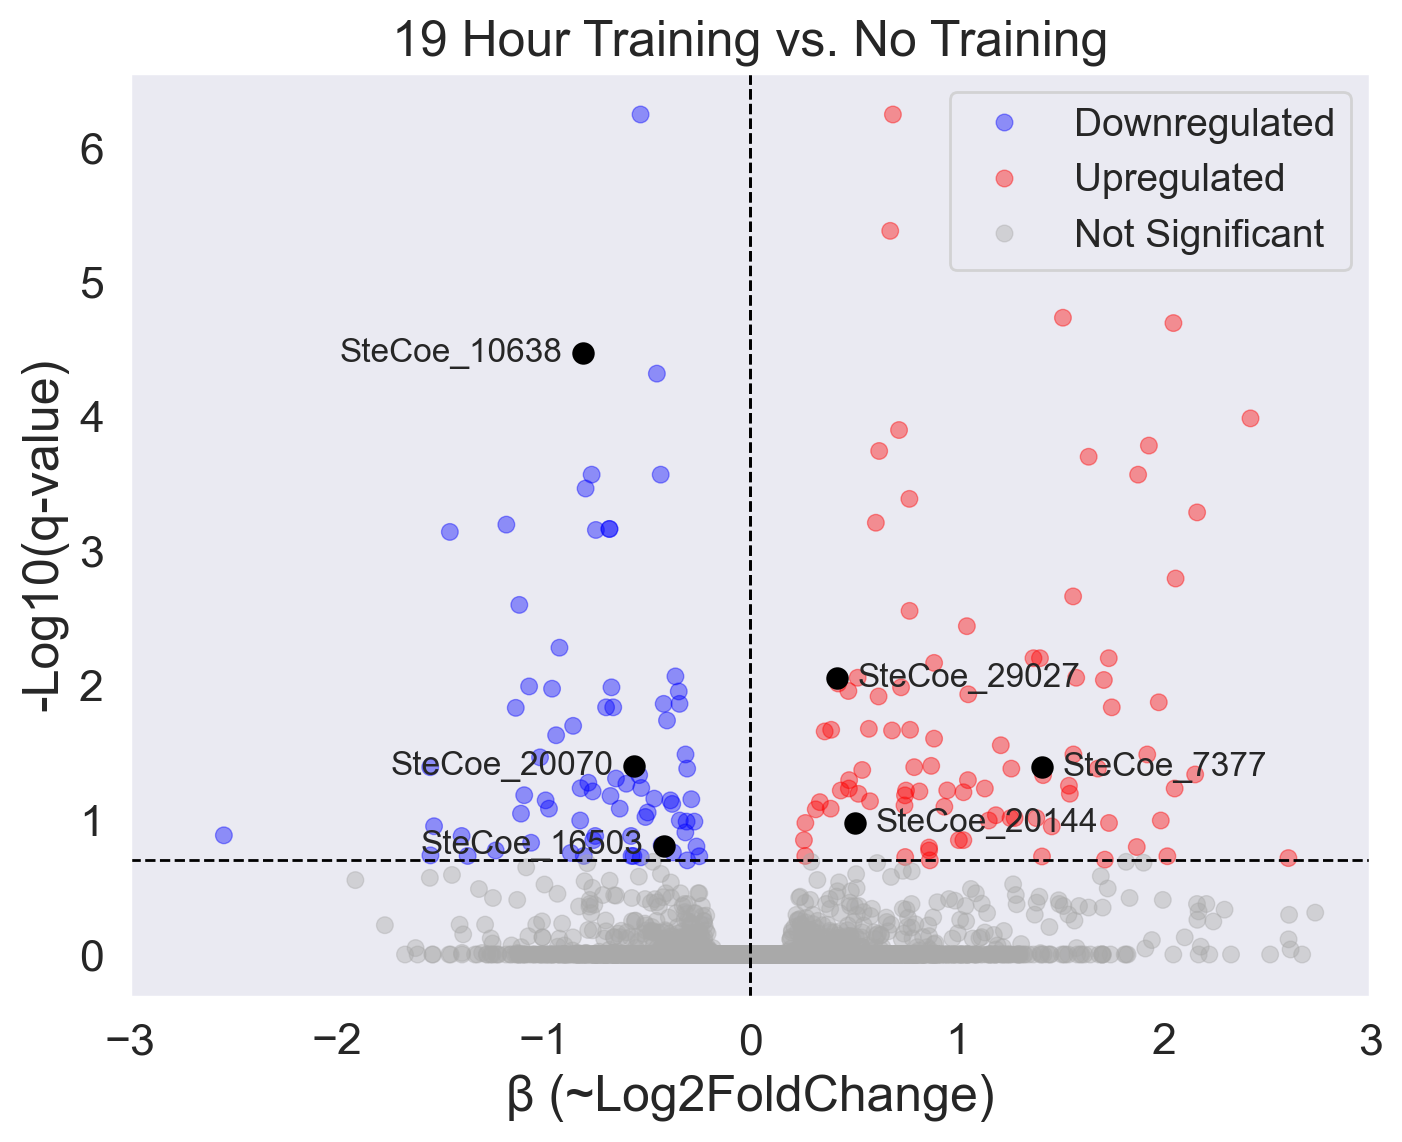

In [14]:
# define significance thresholds
padj_threshold = 0.2 # q-value threshold
logfc_threshold = 0  # Log2 fold change threshold

# significance labels based on q-value
df_19["significant"] = "Not Significant"
df_19.loc[(df_19["b"] > logfc_threshold) & (df_19["qval"] < padj_threshold), "significant"] = "Upregulated"
df_19.loc[(df_19["b"] < -logfc_threshold) & (df_19["qval"] < padj_threshold), "significant"] = "Downregulated"

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_19["b"],
    y=-np.log10(df_19["qval"]),
    hue=df_19["significant"],
    palette={"Upregulated": "red", "Downregulated": "blue", "Not Significant": "darkgray"},
    alpha=0.4, 
    edgecolors=None
)


for gene in gene_list: 
    x = df_19["b"][gene]
    y = -np.log10(df_19["qval"][gene])
    plt.scatter(x, y, color='black', s=50, label=None)

    # label positioning
    ha = 'right' if x < 0 else 'left'
    x_text = x - 0.1 if x < 0 else x + 0.1
    plt.text(x_text, y, gene, fontsize=12, ha=ha, va='center')

# hardcoding text position because overlap

# # SteCoe_7377
# x_29668 = df_19["b"]["SteCoe_7377"]
# y_29668 = -np.log10(df_19["qval"]["SteCoe_7377"])
# plt.scatter(x_29668, y_29668, color='black', s=50)
# plt.text(x_29668 + 0.1, y_29668, "SteCoe_7377", ha='left')  

# # SteCoe_14983
# x_14983 = df_19["b"]["SteCoe_14983"]
# y_14983 = -np.log10(df_19["qval"]["SteCoe_14983"])
# plt.scatter(x_14983, y_14983, color='black', s=50)
# plt.text(x_14983 - 0.1, y_14983, "SteCoe_14983", ha='right')  

# # SteCoe_30681
# x_30681 = df_19["b"]["SteCoe_30681"]
# y_30681 = -np.log10(df_19["qval"]["SteCoe_30681"])
# plt.scatter(x_30681, y_30681, color='black', s=50)
# plt.text(x_30681 + 0.1, y_30681 + 0.1, "SteCoe_30681", ha='left')  

# Add threshold lines
plt.axhline(-np.log10(padj_threshold), linestyle="dashed", color="black", linewidth=1)  # q-value threshold
plt.axvline(-logfc_threshold, linestyle="dashed", color="black", linewidth=1)  # logFC threshold
plt.axvline(logfc_threshold, linestyle="dashed", color="black", linewidth=1)

# set x-axis range 
plt.xlim(-3,3)

# Labels & title
plt.xlabel("β (~Log2FoldChange)")
plt.ylabel("-Log10(q-value)")
plt.legend(title="")
plt.title("19 Hour Training vs. No Training") 

#plt.savefig('fig/exp1_volcano_19.png', dpi=300, bbox_inches='tight')  # Save with high resolution

plt.show()